# Nạp và trực quan hóa kết quả Ablation Study

Notebook xử lý **6 mã cổ phiếu** (`ACB`, `FPT`, `GAS`, `HPG`, `SSI`, `VCB`) và **3 case** (`without_vae`, `without_cost_network`, `without_confident_weighting`).

Notebook thực hiện: (1) tự tìm thư mục dữ liệu, (2) nạp toàn bộ 90 tệp CSV, (3) kiểm tra tính đầy đủ, (4) vẽ so sánh 3 case cho từng cổ phiếu, và (5) vẽ từng case trên toàn bộ cổ phiếu. **Các hình chỉ được hiển thị trong notebook, không được xuất ra tệp.** Dữ liệu CSV gốc không bị thay đổi.

In [3]:
# Kiểm tra môi trường và nạp thư viện.
import sys
import subprocess
import importlib.util

if sys.version_info < (3, 10):
    raise RuntimeError(f'Notebook yêu cầu Python >= 3.10; hiện tại là {sys.version.split()[0]}.')

required = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])

from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 120)

In [4]:
# Cấu hình các mã, case và tự xác định thư mục gốc.
TICKERS = ('ACB', 'FPT', 'GAS', 'HPG', 'SSI', 'VCB')
CASES = ('without_vae', 'without_cost_network', 'without_confident_weighting')
CASE_LABELS = {
    'without_vae': 'Without VAE',
    'without_cost_network': 'Without Cost Network',
    'without_confident_weighting': 'Without Confidence Weighting',
}
CASE_COLORS = {
    'without_vae': '#3568B8',
    'without_cost_network': '#E58B2A',
    'without_confident_weighting': '#4C9A68',
}

def find_data_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if all((candidate / ticker).is_dir() for ticker in TICKERS):
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục chứa đủ: ' + ', '.join(TICKERS))

DATA_ROOT = find_data_root(Path.cwd())

In [5]:
# Lập danh mục và nạp TOÀN BỘ CSV trong 6 mã x 3 case.
catalog_rows = []
for ticker in TICKERS:
    for case in CASES:
        case_dir = DATA_ROOT / ticker / case
        if not case_dir.is_dir():
            continue
        for path in sorted(case_dir.glob('*.csv')):
            catalog_rows.append({
                'ticker': ticker, 'case': case, 'dataset': path.stem,
                'size_bytes': path.stat().st_size,
                'relative_path': path.relative_to(DATA_ROOT).as_posix(), 'path': path,
            })

file_catalog = pd.DataFrame(catalog_rows)
csv_data = {ticker: {case: {} for case in CASES} for ticker in TICKERS}
frames_by_name = {}
load_rows = []

for row in file_catalog.itertuples(index=False):
    frame = pd.read_csv(row.path, low_memory=False)
    csv_data[row.ticker][row.case][row.dataset] = frame
    enriched = frame.copy()
    enriched.insert(0, '_source_file', row.relative_path)
    enriched.insert(0, '_case', row.case)
    enriched.insert(0, '_ticker_folder', row.ticker)
    frames_by_name.setdefault(row.dataset, []).append(enriched)
    load_rows.append({
        'ticker': row.ticker, 'case': row.case, 'dataset': row.dataset,
        'rows': len(frame), 'columns': len(frame.columns), 'file': row.relative_path,
    })

combined = {name: pd.concat(frames, ignore_index=True, sort=False) for name, frames in frames_by_name.items()}
csv_inventory = pd.DataFrame(load_rows).sort_values(['dataset', 'ticker', 'case']).reset_index(drop=True)

In [6]:
# Kiểm tra dữ liệu và gom kết quả vào một biến duy nhất.
EXPECTED_DATASETS = {
    'ablation_summary', 'rl_episode_curves', 'rl_losses',
    'rl_metrics', 'rl_test_portfolios',
}
issues = []
for ticker in TICKERS:
    for case in CASES:
        found = set(csv_data[ticker][case])
        missing = EXPECTED_DATASETS - found
        if missing:
            issues.append(f'{ticker}/{case} thiếu: {sorted(missing)}')

all_data = {
    'root': DATA_ROOT, 'tickers': TICKERS, 'cases': CASES,
    'catalog': file_catalog, 'csv': csv_data, 'combined': combined,
    'csv_inventory': csv_inventory,
}

if issues:
    raise ValueError('Dữ liệu chưa đầy đủ:\n' + '\n'.join(f'- {issue}' for issue in issues))

## Cách truy cập nhanh

- Một bảng gốc: `all_data['csv']['ACB']['without_vae']['rl_metrics']`
- Bảng gộp cả 6 mã và 3 case: `all_data['combined']['rl_metrics']`
- Bảng tổng hợp dùng để vẽ: `all_data['combined']['ablation_summary']`
- Danh mục tất cả tệp: `all_data['catalog']`

In [13]:
all_data['combined']['ablation_summary']

,_ticker_folder,_case,_source_file,ticker,period,model_key,model,runs,test_profit_mean,test_profit_std,test_profit_median,test_profit_q25,test_profit_q75,test_profit_valid_n,test_roi_mean,test_roi_std,test_roi_median,test_roi_q25,test_roi_q75,test_roi_valid_n,test_arr_mean,test_arr_std,test_arr_median,test_arr_q25,test_arr_q75,test_arr_valid_n,test_volatility_mean,test_volatility_std,test_volatility_median,test_volatility_q25,test_volatility_q75,test_volatility_valid_n,test_sharpe_mean,test_sharpe_std,test_sharpe_median,test_sharpe_q25,test_sharpe_q75,test_sharpe_valid_n,test_max_drawdown_mean,test_max_drawdown_std,test_max_drawdown_median,test_max_drawdown_q25,test_max_drawdown_q75,test_max_drawdown_valid_n,test_violations_mean,test_violations_std,test_violations_median,test_violations_q25,test_violations_q75,test_violations_valid_n,test_collapse_rate,test_no_trade_rate,test_invalid_action_rate_mean
0,ACB,without_vae,ACB/without_vae/ablation_summary.csv,ACB,BAD,UCB_WITHOUT_VAE_UNCERTAINTY,UCB-VAE without VAE uncertainty,20,21.056436,51.243681,26.819000,-3.617438,45.489962,20,2.105644,5.124368,2.681900,-0.361744,4.548996,20,1.020586,2.550208,1.336679,-0.181661,2.257013,20,13.414458,8.481797,12.546247,6.786663,19.388625,20,-0.095666,0.396056,0.051808,-0.129042,0.108443,20,18.048810,12.267566,13.315194,7.807677,26.164509,20,1.95,2.910507,0.0,0.00,2.75,20,0.0,0.0,0.0
1,ACB,without_cost_network,ACB/without_cost_network/ablation_summary.csv,ACB,BAD,UCB_WITHOUT_COST_NETWORK,UCB-VAE without Cost Network,20,17.197359,55.128634,12.199720,-2.408153,39.630797,20,1.719736,5.512863,1.219972,-0.240815,3.963080,20,0.823812,2.748610,0.610136,-0.120937,1.968956,20,13.203435,8.747545,12.221763,5.002424,19.584009,20,-0.122325,0.390900,-0.037649,-0.293120,0.088196,20,17.699349,12.393650,14.415423,6.592572,25.503498,20,2.00,2.973568,0.0,0.00,2.75,20,0.0,0.0,0.0
2,ACB,without_confident_weighting,ACB/without_confident_weighting/ablation_summa...,ACB,BAD,UCB_WITHOUT_CONFIDENCE_WEIGHTING,UCB-VAE without Confidence Weighting,20,17.976128,53.250434,26.658460,-6.052155,48.500898,20,1.797613,5.325043,2.665846,-0.605215,4.850090,20,0.864185,2.684610,1.328729,-0.304194,2.404214,20,13.204521,8.522422,9.476178,6.571175,20.998916,20,-0.056256,0.312899,0.048240,-0.157039,0.138759,20,18.062281,12.253373,14.634649,7.493262,27.940325,20,2.05,2.999561,0.0,0.00,3.50,20,0.0,0.0,0.0
3,FPT,without_vae,FPT/without_vae/ablation_summary.csv,FPT,BAD,UCB_WITHOUT_VAE_UNCERTAINTY,UCB-VAE without VAE uncertainty,20,216.963721,190.221482,161.894875,111.323460,292.340443,20,21.696372,19.022148,16.189488,11.132346,29.234044,20,10.048632,8.436436,7.818593,5.438254,13.716361,20,15.332797,5.764091,16.720086,10.614416,18.428368,20,0.506859,0.553404,0.503943,0.268278,0.784800,20,19.145931,8.185261,19.883786,13.700310,25.576030,20,1.40,1.391705,1.0,0.00,2.00,20,0.0,0.0,0.0
4,FPT,without_cost_network,FPT/without_cost_network/ablation_summary.csv,FPT,BAD,UCB_WITHOUT_COST_NETWORK,UCB-VAE without Cost Network,20,217.496938,187.137864,191.095525,92.028327,321.684548,20,21.749694,18.713786,19.109553,9.202833,32.168455,20,10.075218,8.404832,9.167112,4.514036,15.015954,20,15.668688,5.724820,16.642307,11.246522,19.269129,20,0.462884,0.623925,0.478836,0.223310,0.781977,20,19.473414,7.237762,20.569756,14.265414,24.265854,20,1.45,1.356272,1.0,0.00,2.25,20,0.0,0.0,0.0
5,FPT,without_confident_weighting,FPT/without_confident_weighting/ablation_summa...,FPT,BAD,UCB_WITHOUT_CONFIDENCE_WEIGHTING,UCB-VAE without Confidence Weighting,20,219.830494,188.244506,167.836325,87.145688,315.447135,20,21.983049,18.824451,16.783632,8.714569,31.544714,20,10.189005,8.301639,8.095123,4.281067,14.739405,20,15.803072,5.837071,16.919802,12.101089,20.632013,20,0.529873,0.475881,0.515586,0.239805,0.807620,20,19.601938,8.502197,20.242930,15.454721,26.334587,20,1.70,1.525226,1.5,0.00,3.00,20,0.0,0.0,0.0
6,GAS,without_vae,GAS/without_vae/ablation_summary.csv,GAS,BAD,UCB_WITHOUT_VAE_UNCERTAINTY,UCB-VAE without VAE uncertainty,

In [7]:
# Cấu hình chung cho các biểu đồ.
%matplotlib inline
METRICS = {
    'test_profit_mean': 'Profit trung bình',
    'test_roi_mean': 'ROI trung bình (%)',
    'test_arr_mean': 'ARR trung bình (%)',
    'test_volatility_mean': 'Volatility trung bình (%)',
    'test_sharpe_mean': 'Sharpe trung bình',
    'test_max_drawdown_mean': 'Max drawdown trung bình (%)',
    'test_violations_mean': 'Violations trung bình',
}
summary = all_data['combined']['ablation_summary'].copy()

def numeric_values(frame, column):
    return pd.to_numeric(frame[column], errors='coerce').to_numpy(dtype=float)

def annotate_bars(ax, bars, values, errors=None):
    for index, (bar, value) in enumerate(zip(bars, values)):
        if not np.isfinite(value):
            continue
        error = 0.0 if errors is None or not np.isfinite(errors[index]) else float(errors[index])
        label = f'{value:,.2f}' + (f'\n±{error:,.2f}' if errors is not None else '')
        label_y = value + error if value >= 0 else value - error
        ax.annotate(
            label, xy=(bar.get_x() + bar.get_width() / 2, label_y),
            xytext=(0, 4 if value >= 0 else -4), textcoords='offset points',
            ha='center', va='bottom' if value >= 0 else 'top',
            fontsize=7.1, color='#222222', clip_on=False,
        )

def style_axis(ax, ylabel):
    ax.axhline(0, color='#888888', linewidth=0.7, zorder=1)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.2f}'))
    ax.margins(y=0.23)
    ax.grid(axis='y', alpha=0.22, linewidth=0.8, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)

## 1. Mỗi cổ phiếu — so sánh cả 3 case

Mỗi mã sinh một hình gồm 7 chỉ số. Mỗi chỉ số có 3 cột tương ứng với 3 case; thanh sai số là độ lệch chuẩn của 20 lần chạy.

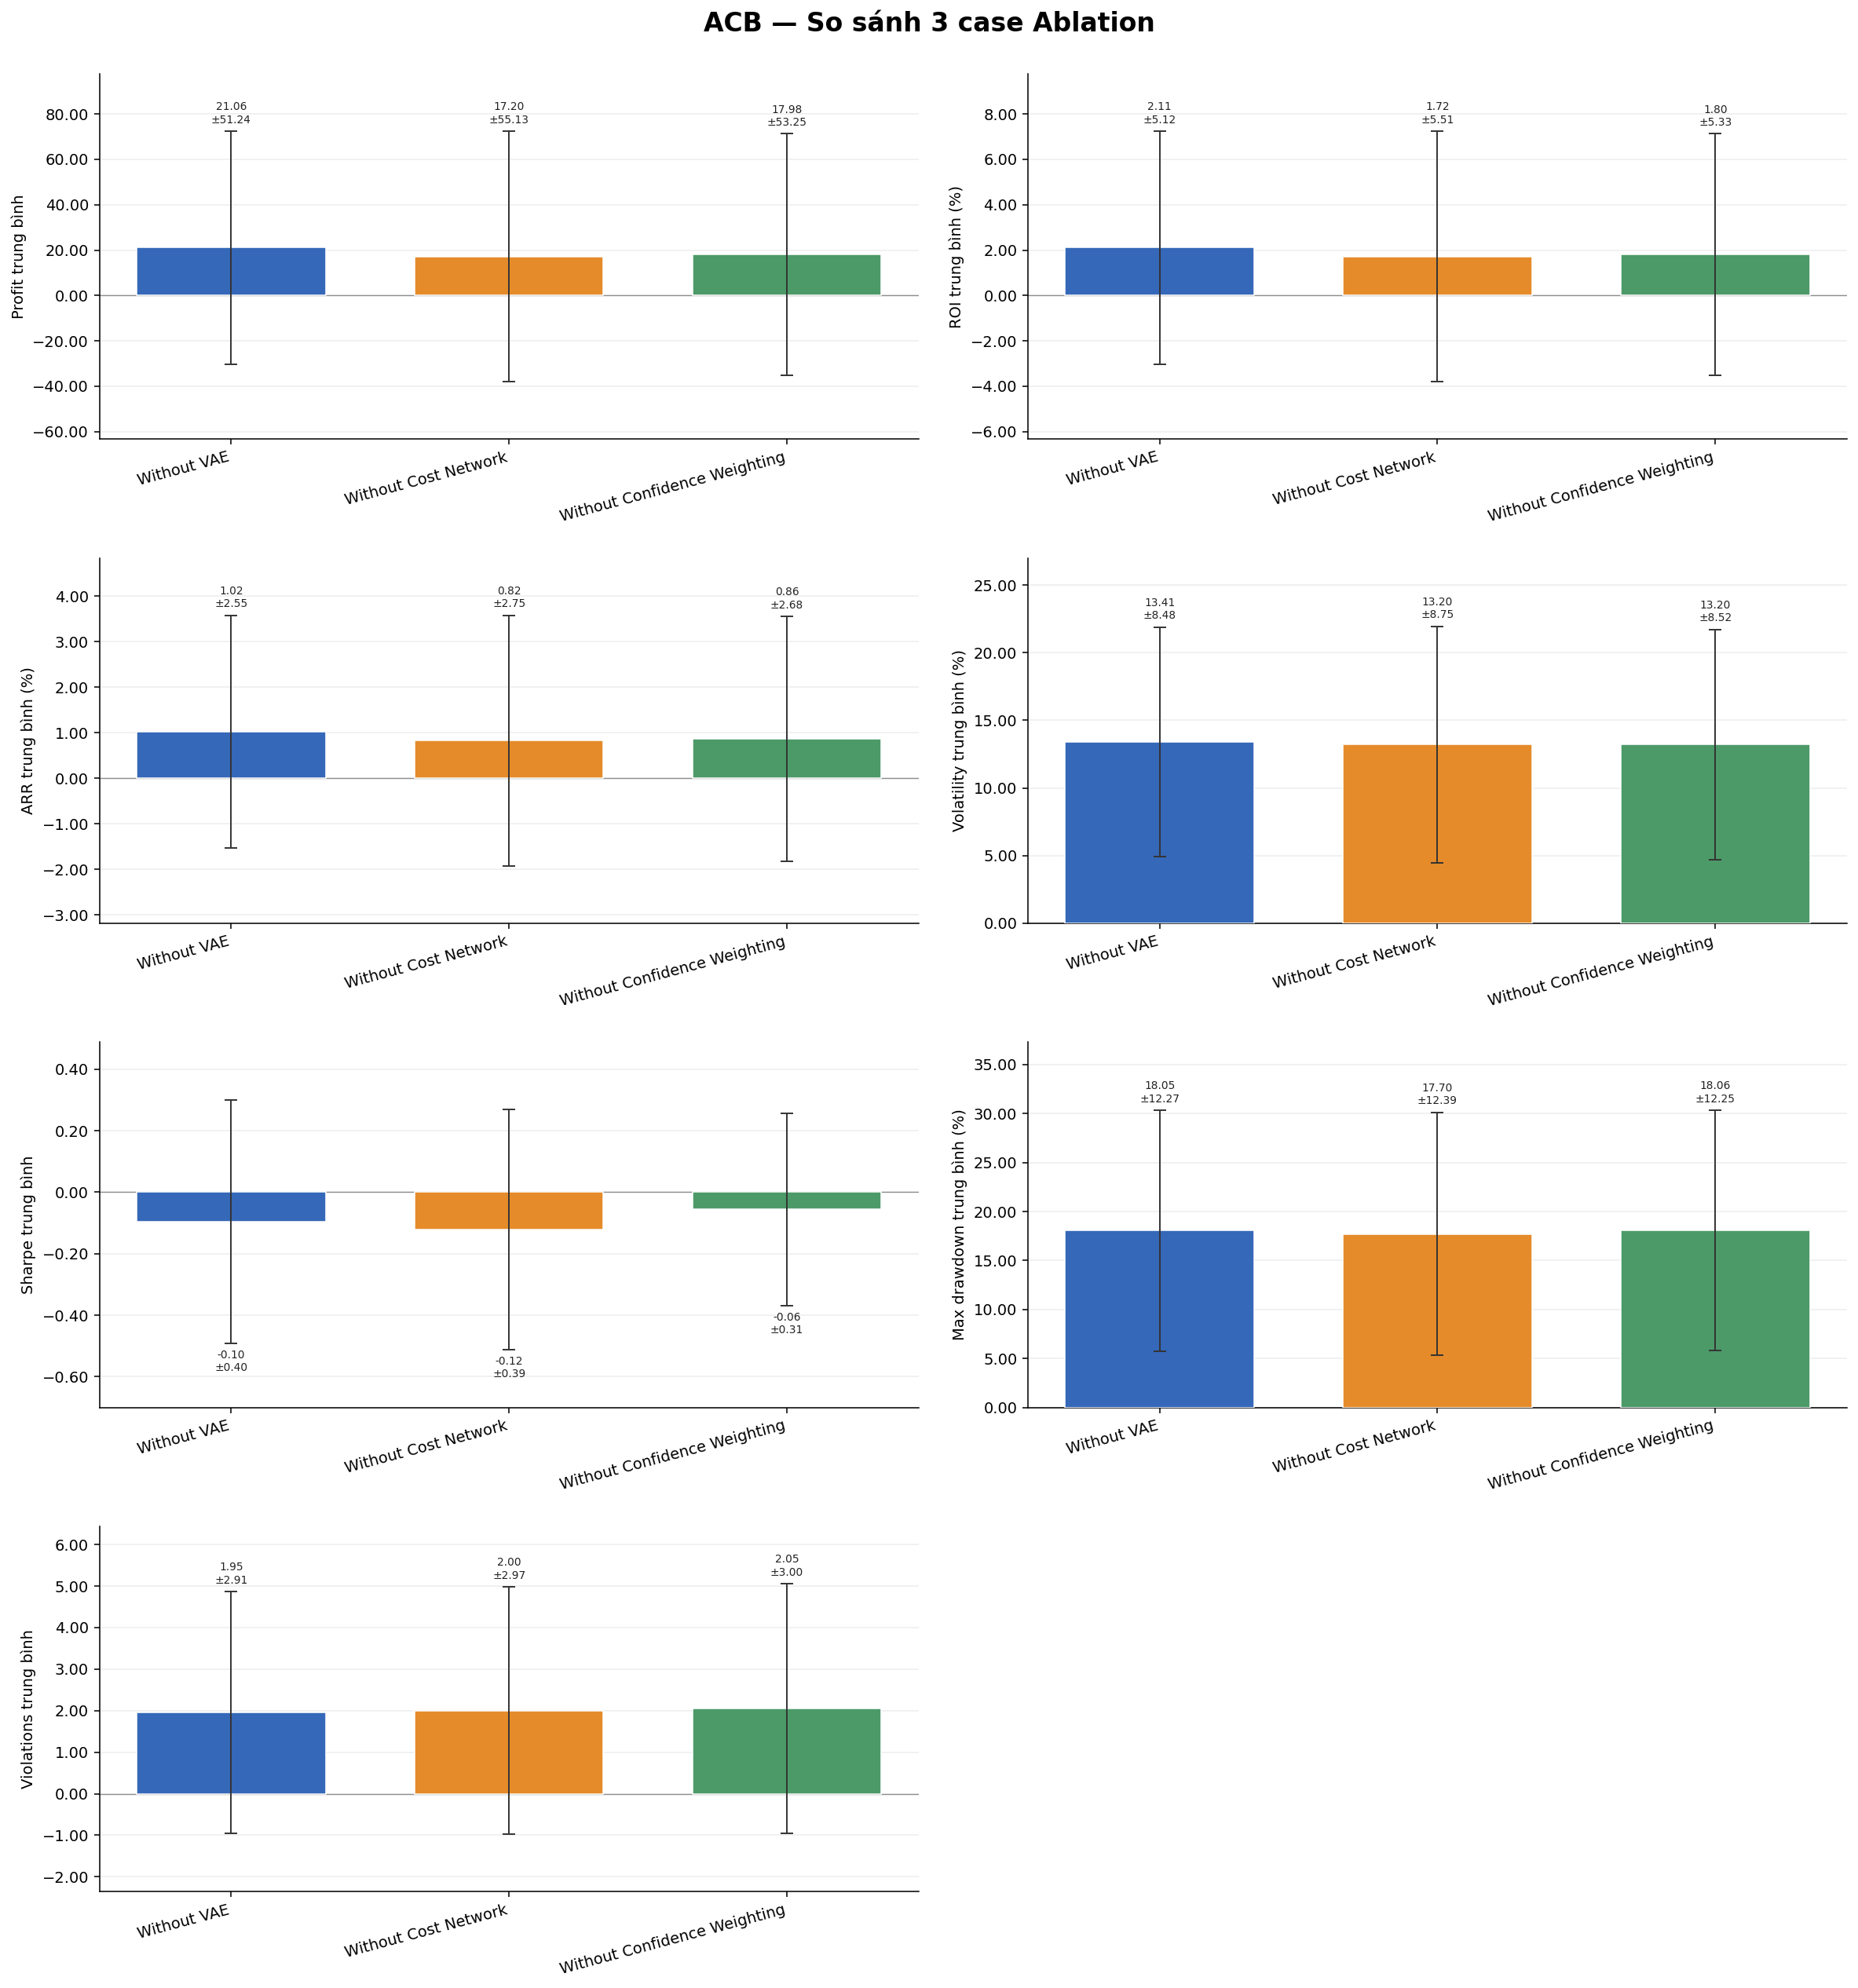

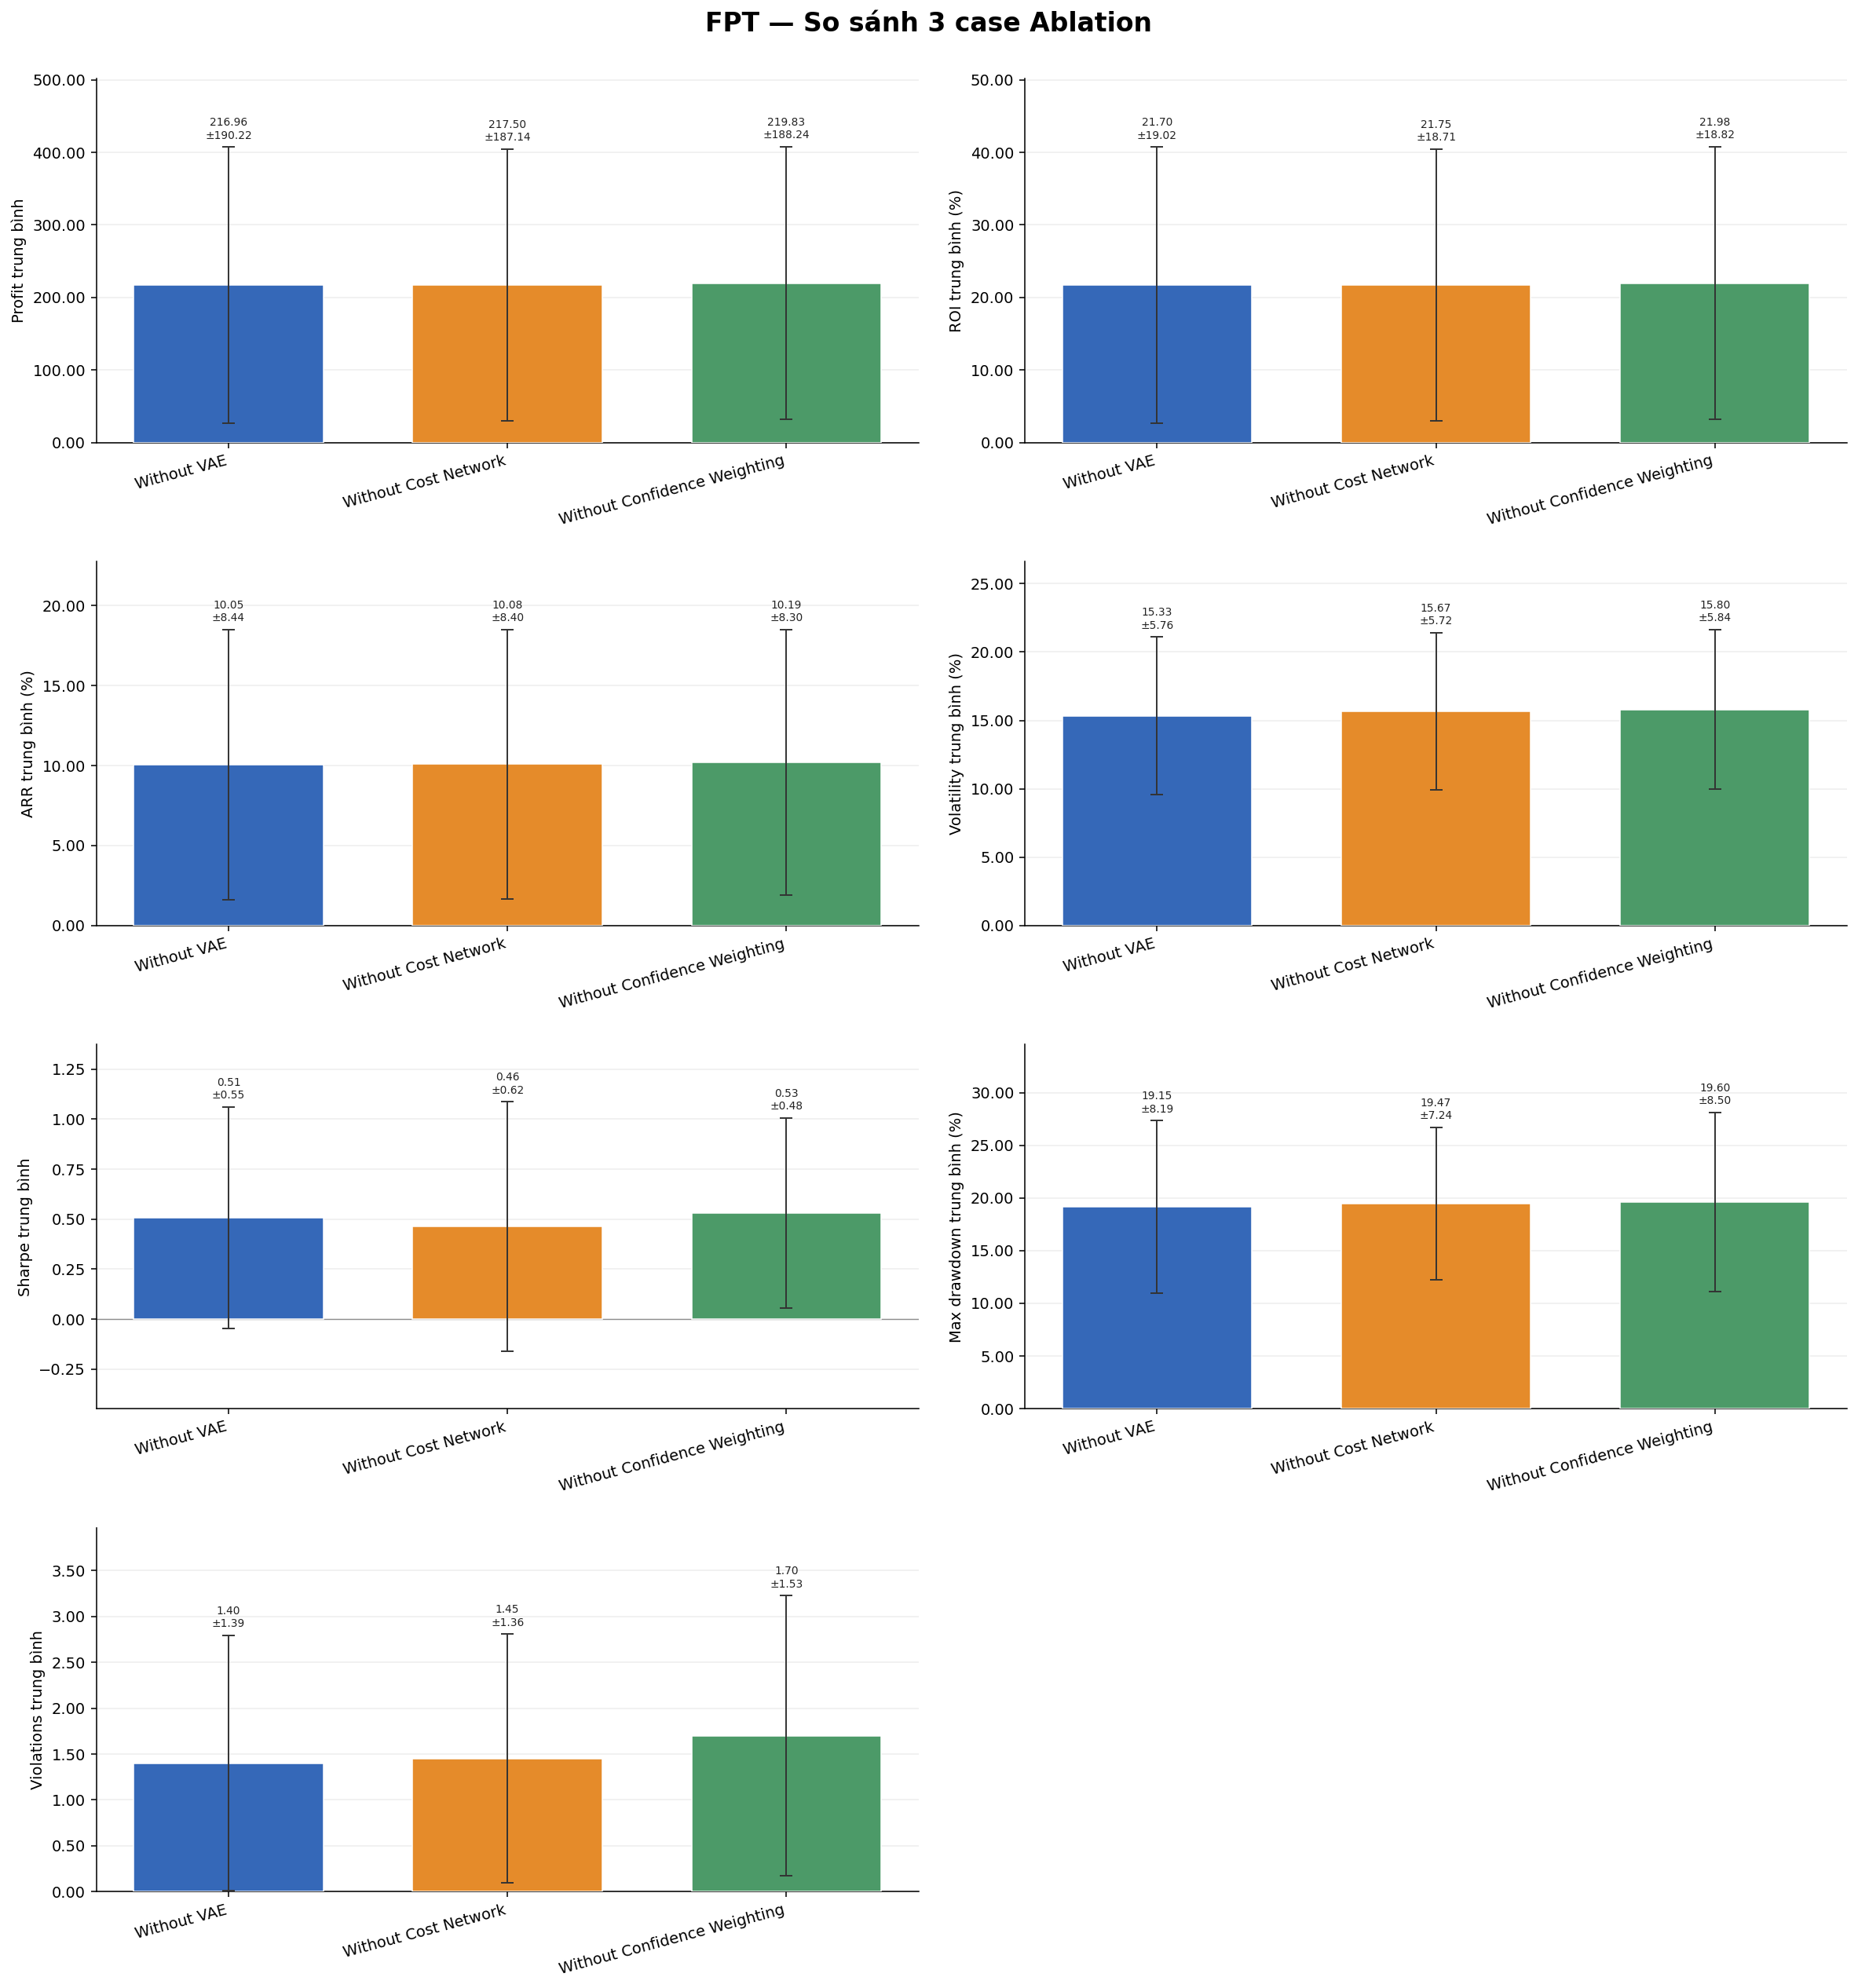

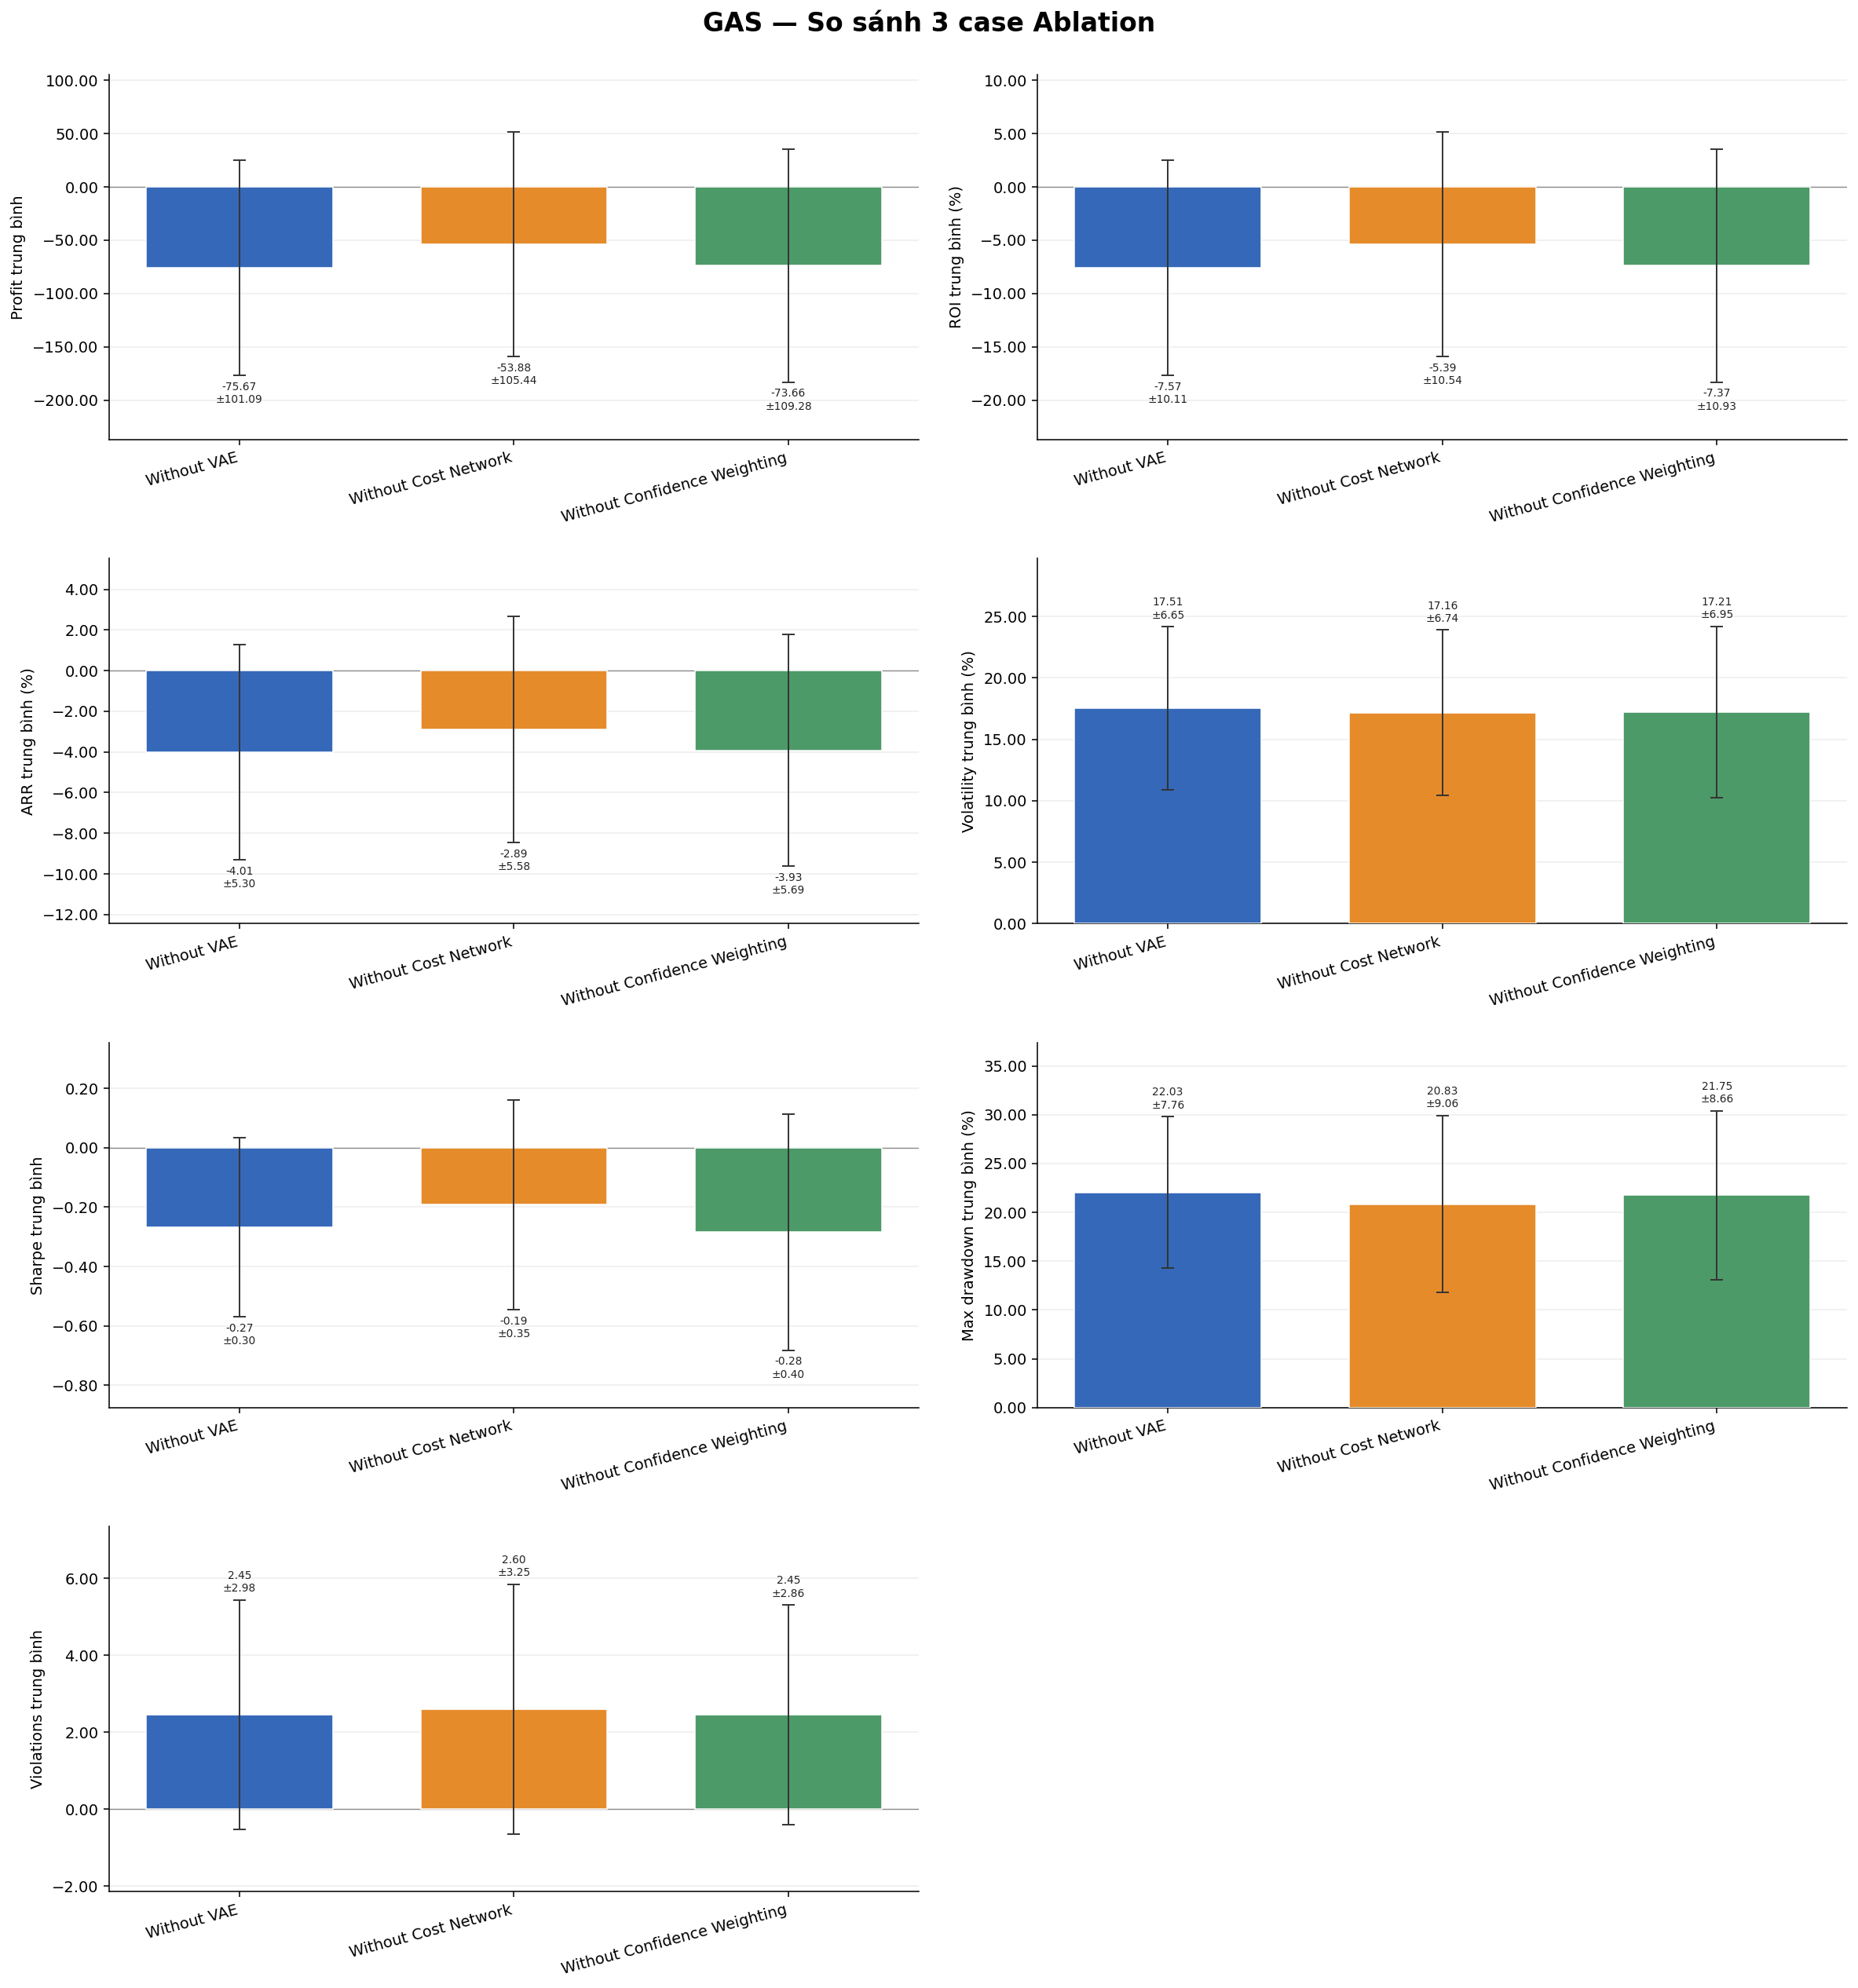

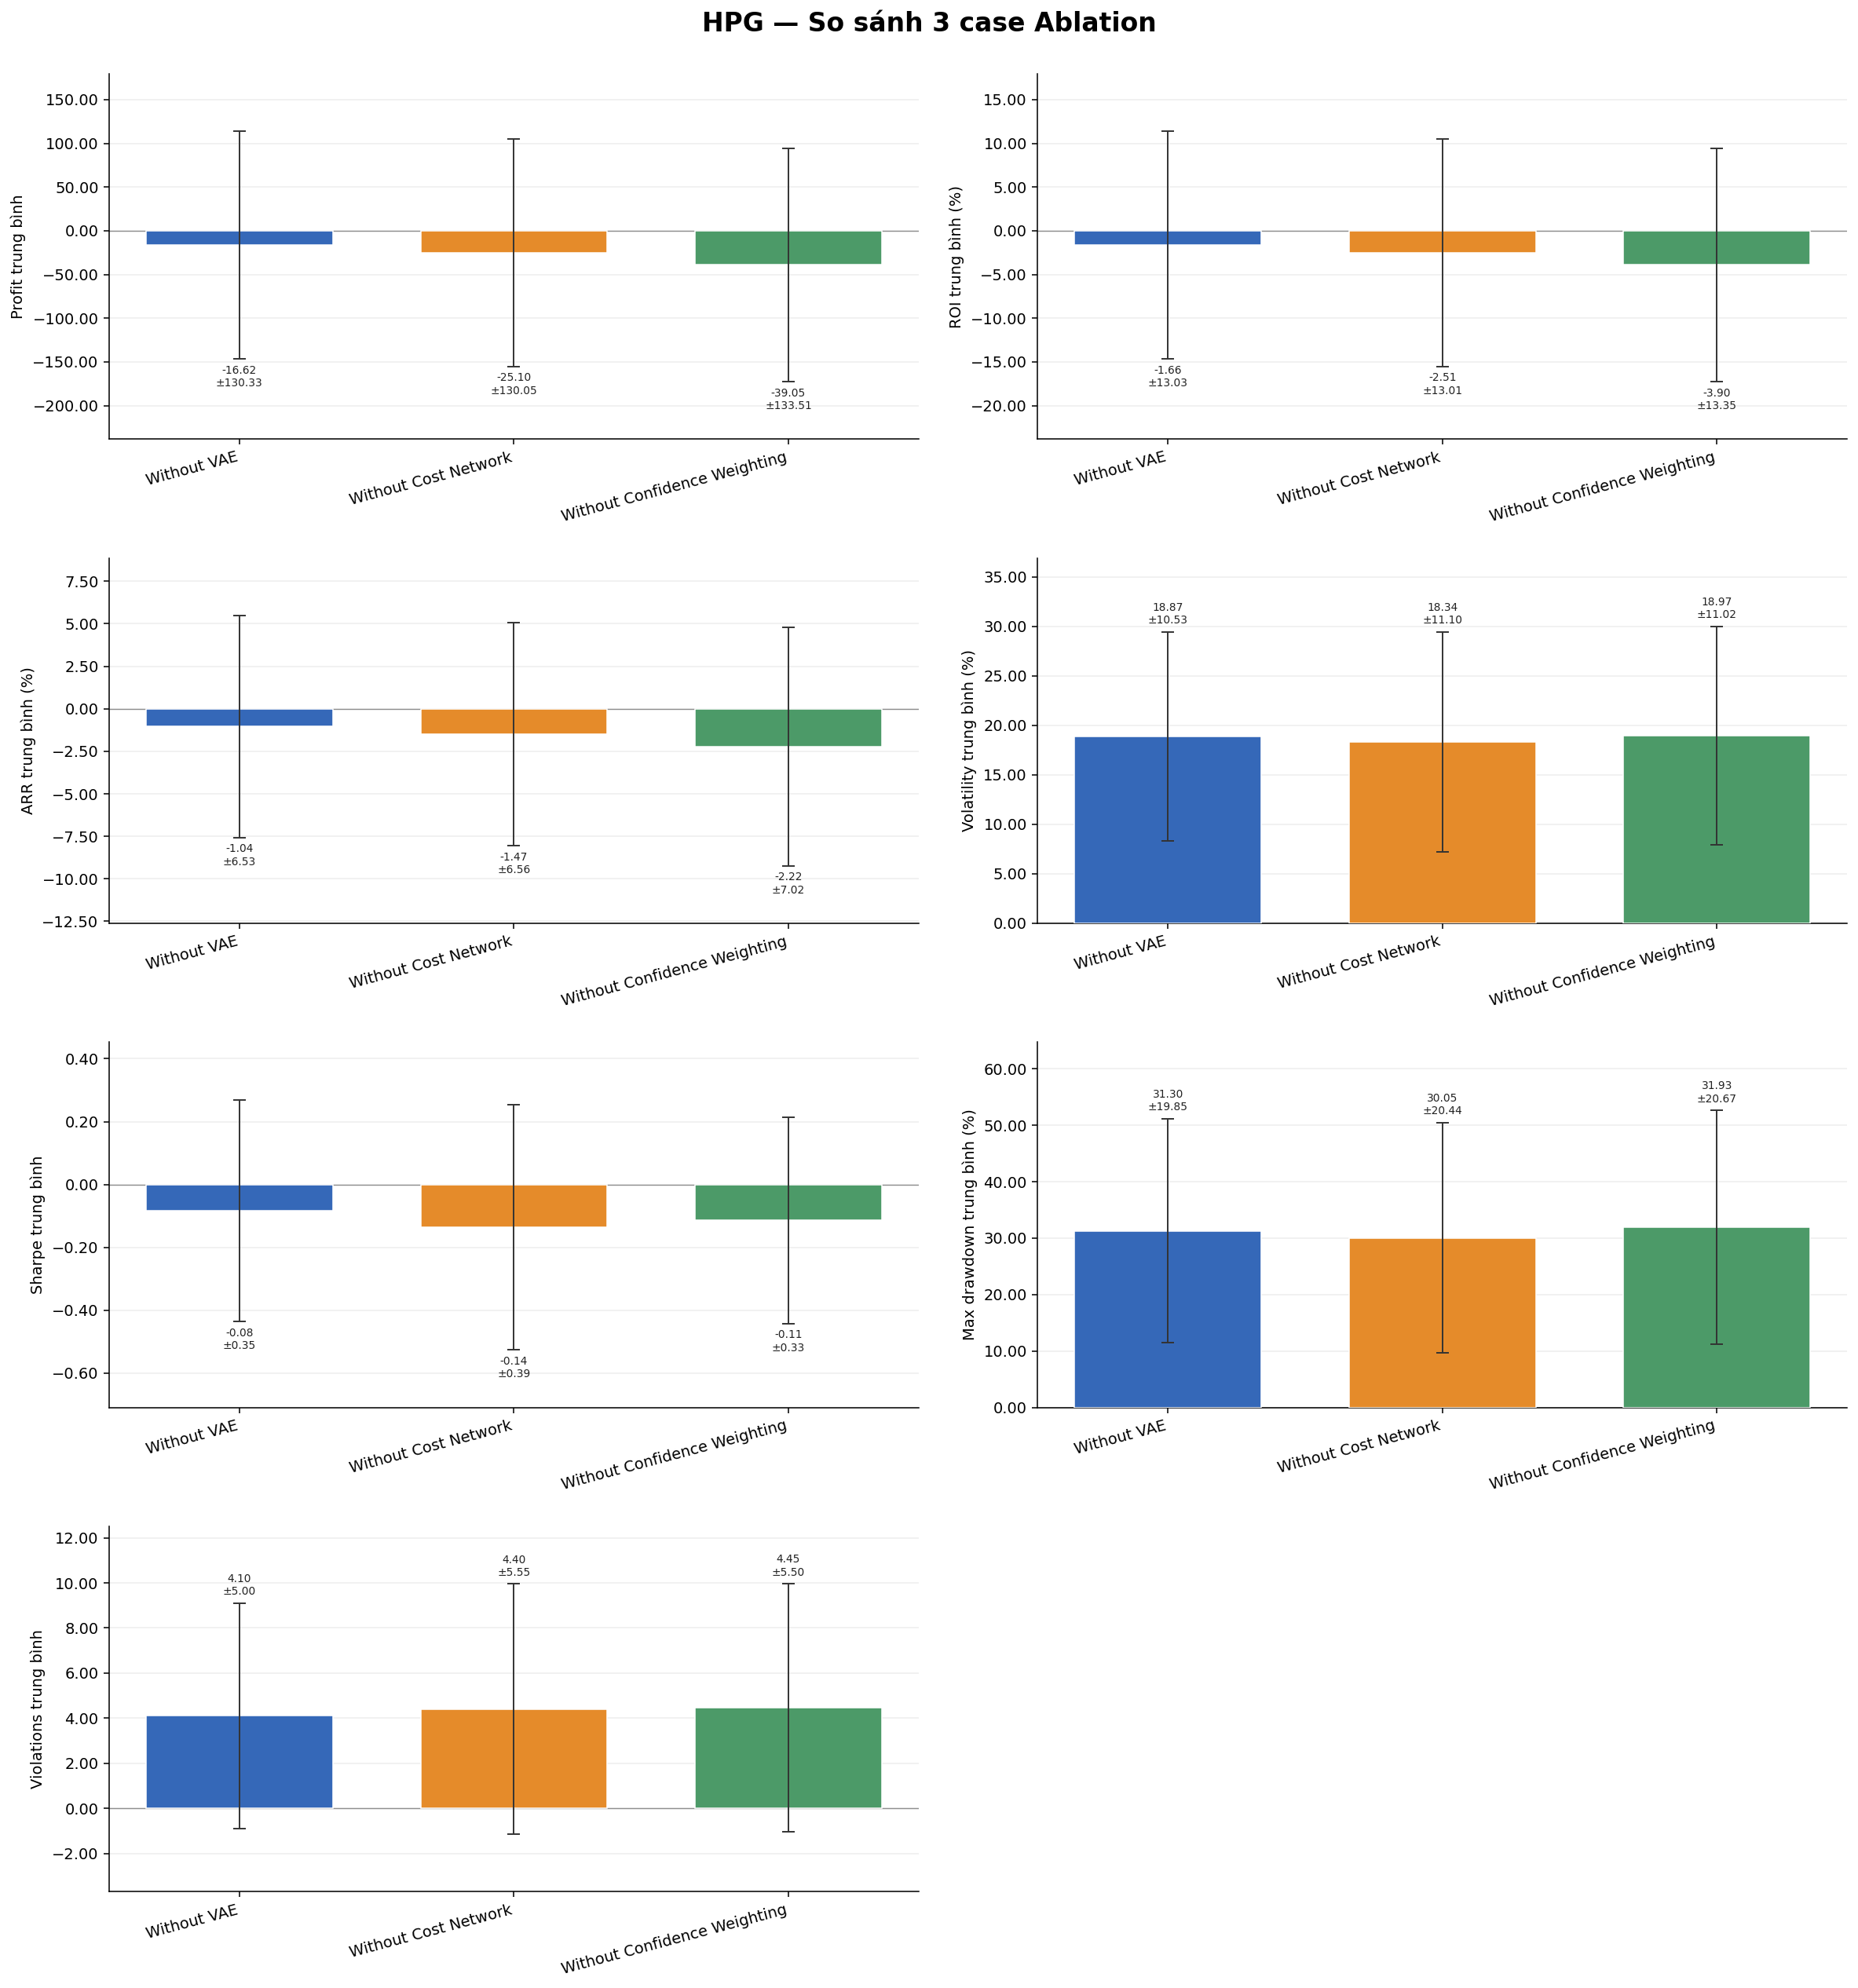

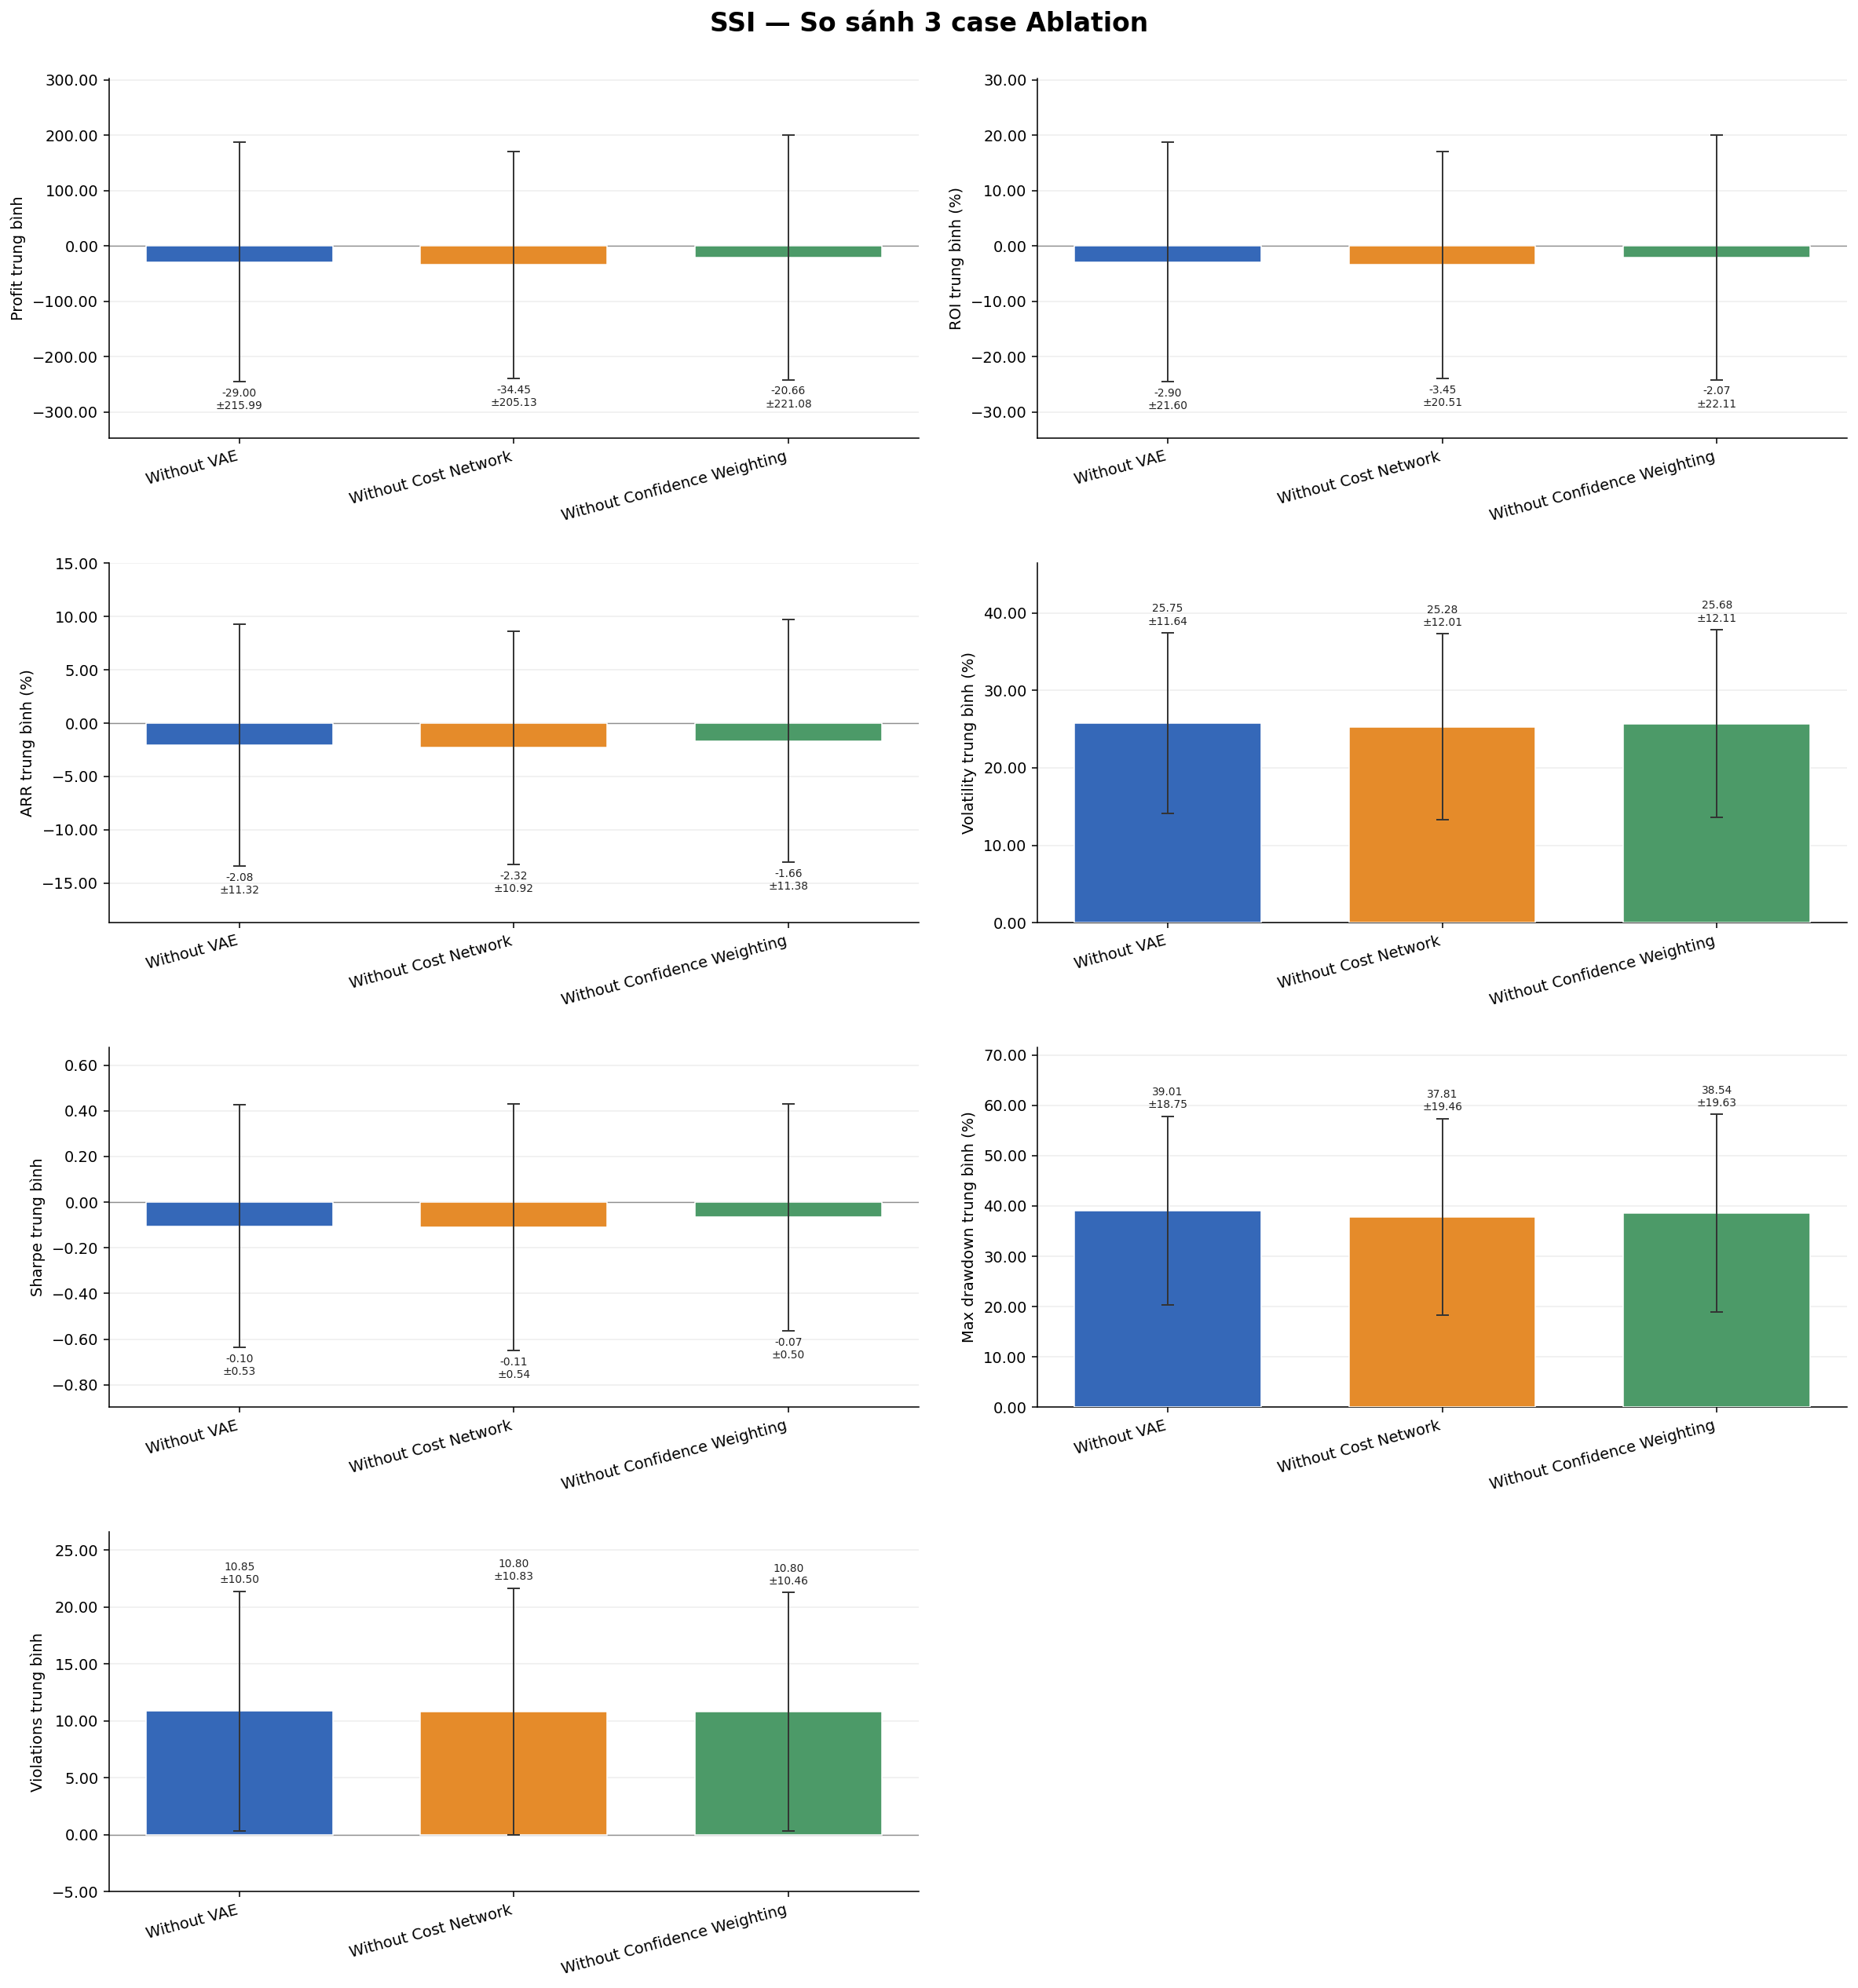

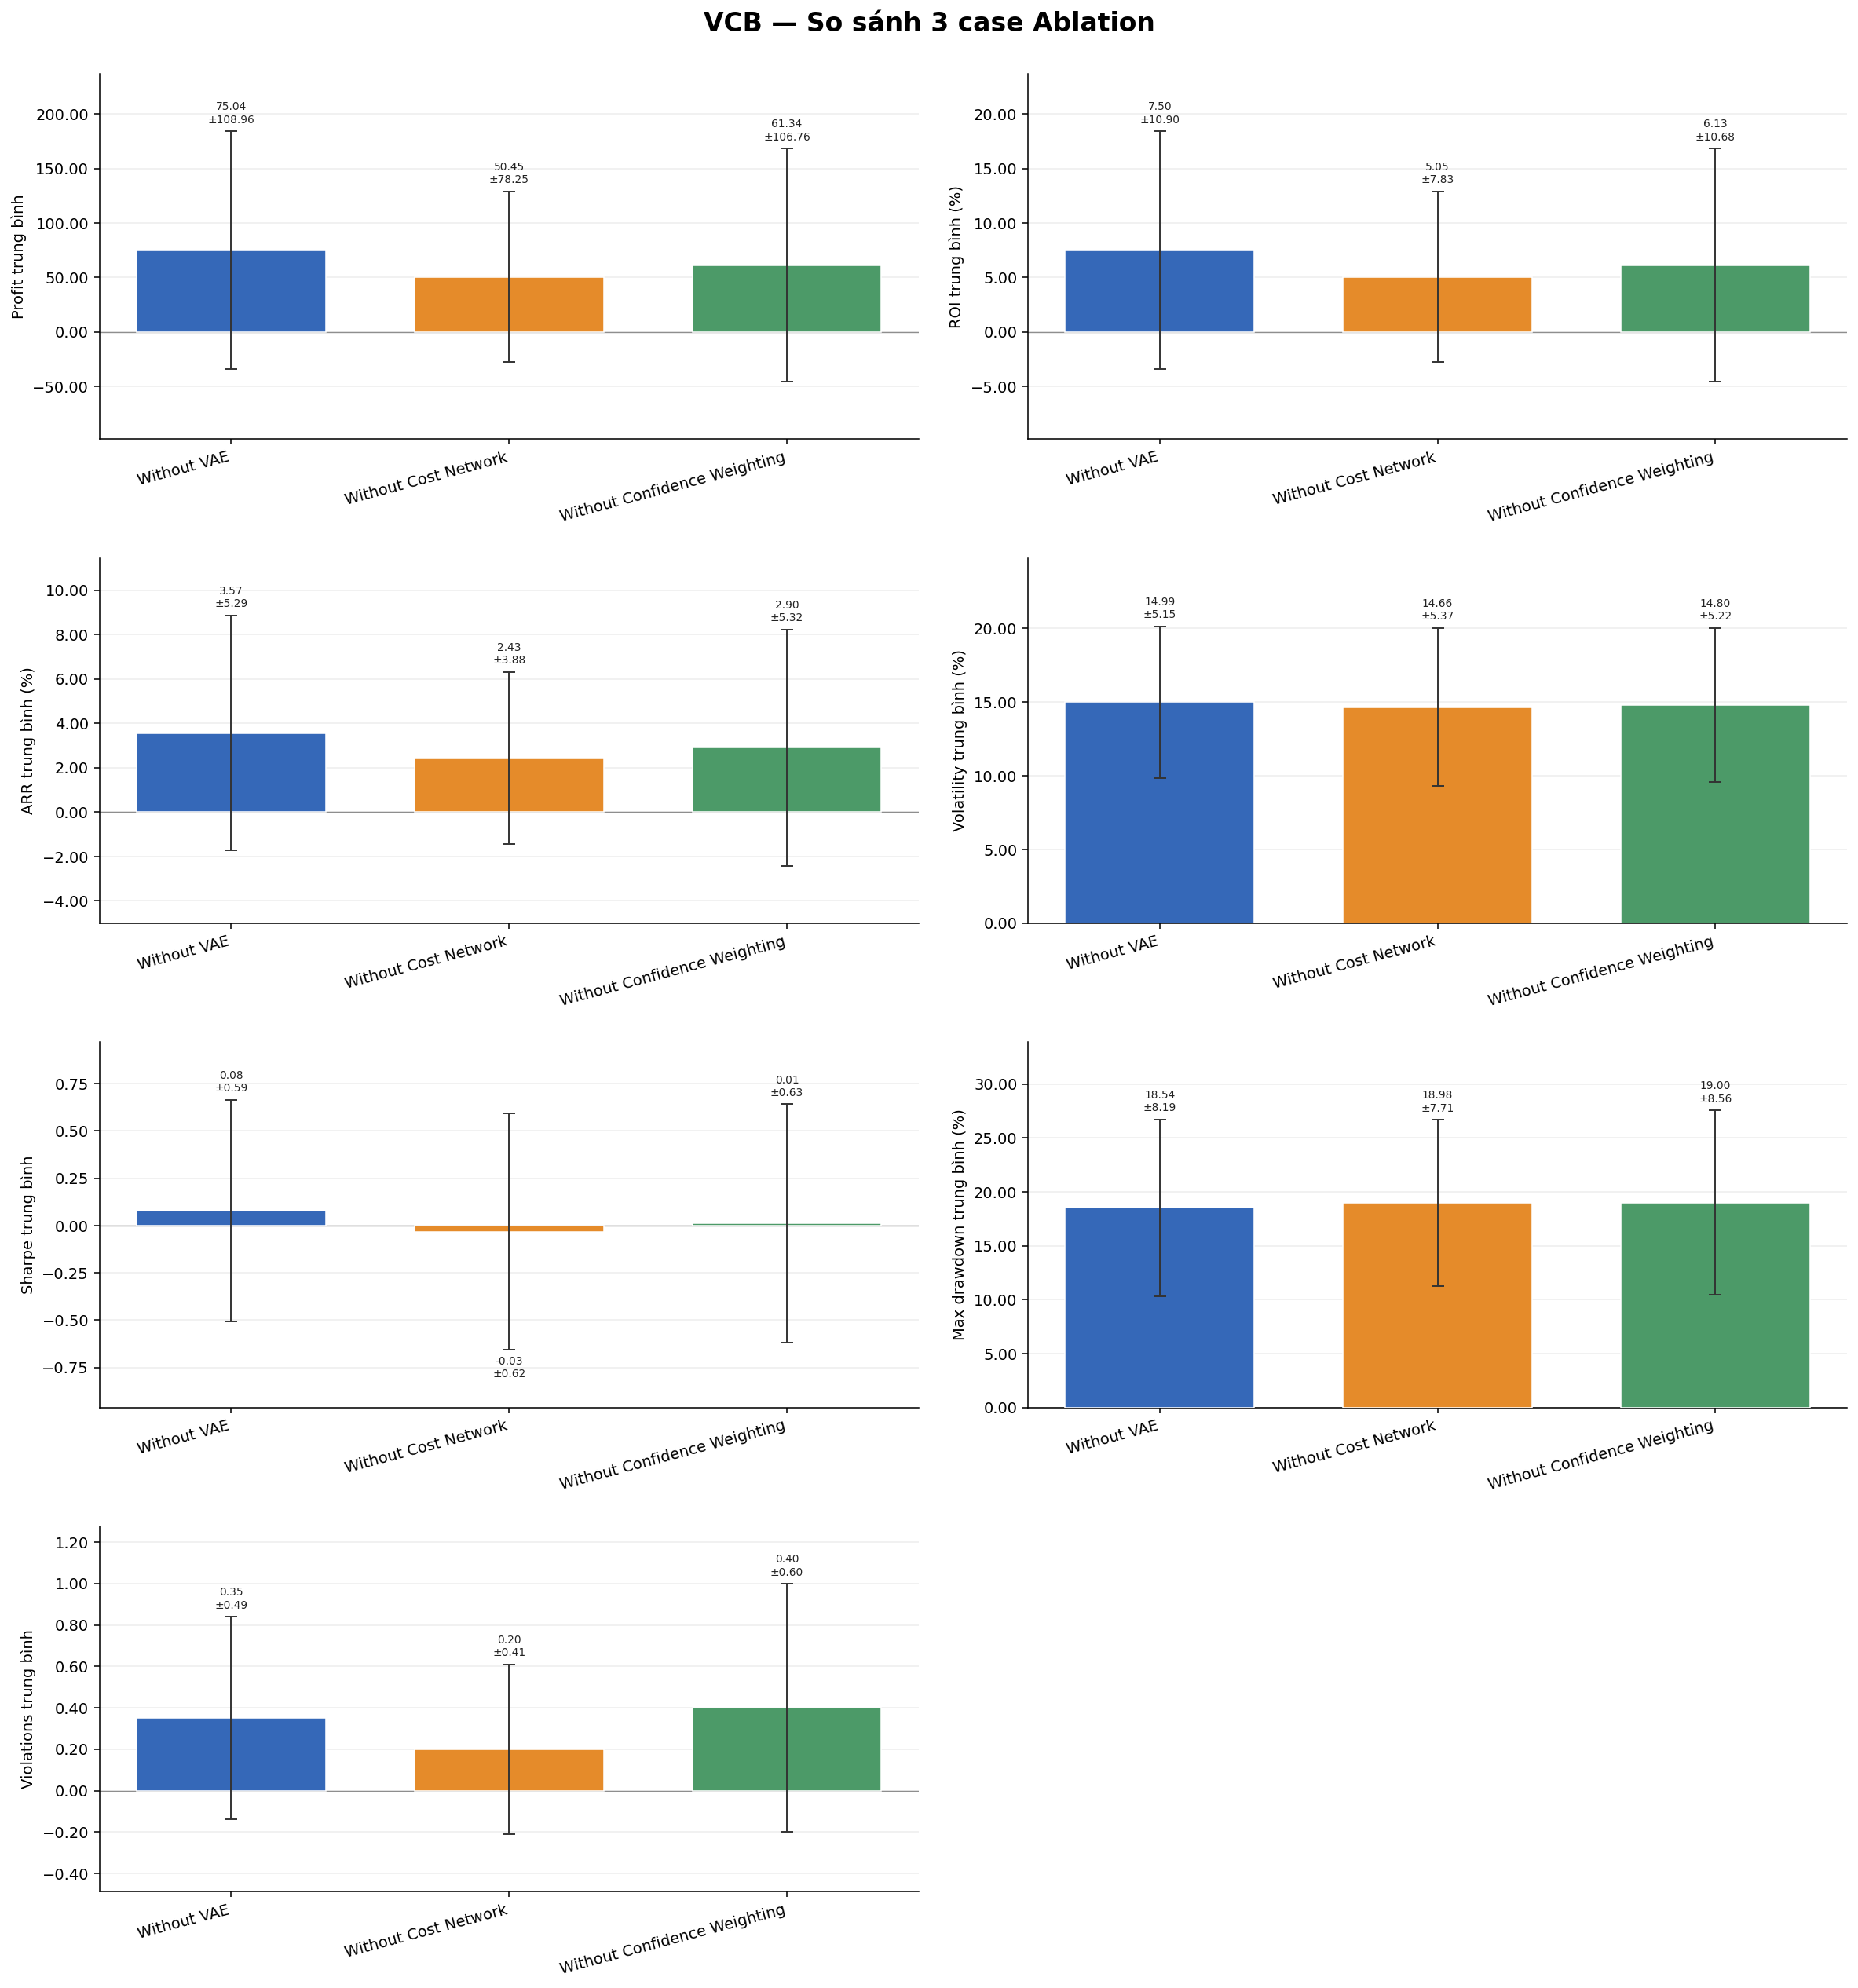

In [8]:
for ticker in TICKERS:
    ticker_data = summary[summary['_ticker_folder'].eq(ticker)].set_index('_case').reindex(CASES)
    fig, axes = plt.subplots(4, 2, figsize=(17, 18), dpi=140)

    for ax, (metric, ylabel) in zip(axes.flat, METRICS.items()):
        values = numeric_values(ticker_data, metric)
        std_column = metric.replace('_mean', '_std')
        errors = numeric_values(ticker_data, std_column) if std_column in ticker_data else None
        x = np.arange(len(CASES))
        bars = ax.bar(
            x, values, width=0.68, color=[CASE_COLORS[case] for case in CASES],
            yerr=errors, capsize=4, edgecolor='white', linewidth=0.8, zorder=3,
            error_kw={'elinewidth': 1, 'ecolor': '#333333'},
        )
        annotate_bars(ax, bars, values, errors)
        ax.set_xticks(x, [CASE_LABELS[case] for case in CASES], rotation=15, ha='right')
        style_axis(ax, ylabel)

    axes.flat[-1].axis('off')
    fig.suptitle(f'{ticker} — So sánh 3 case Ablation', fontsize=17, fontweight='bold', y=1.002)
    fig.tight_layout(h_pad=2.2, w_pad=2.0)
    plt.show()
    plt.close(fig)

## 2. Mỗi case — so sánh trên toàn bộ cổ phiếu

Mỗi case sinh một hình gồm 7 chỉ số và đủ 6 mã cổ phiếu; thanh sai số là độ lệch chuẩn của 20 lần chạy. Mỗi hình được đặt ngay dưới cell Markdown ghi tên case tương ứng.

In [9]:
ticker_colors = ['#3568B8', '#E58B2A', '#4C9A68', '#B84A4A', '#7B61A8', '#4F8C8D']

def plot_case_across_tickers(case):
    case_data = summary[summary['_case'].eq(case)].set_index('_ticker_folder').reindex(TICKERS)
    fig, axes = plt.subplots(4, 2, figsize=(17, 18), dpi=140)

    for ax, (metric, ylabel) in zip(axes.flat, METRICS.items()):
        values = numeric_values(case_data, metric)
        std_column = metric.replace('_mean', '_std')
        errors = numeric_values(case_data, std_column) if std_column in case_data else None
        x = np.arange(len(TICKERS))
        bars = ax.bar(
            x, values, width=0.68, color=ticker_colors, yerr=errors, capsize=4,
            edgecolor='white', linewidth=0.8, zorder=3,
            error_kw={'elinewidth': 1, 'ecolor': '#333333'},
        )
        annotate_bars(ax, bars, values, errors)
        ax.set_xticks(x, TICKERS)
        style_axis(ax, ylabel)

    axes.flat[-1].axis('off')
    fig.tight_layout(h_pad=2.2, w_pad=2.0)
    plt.show()
    plt.close(fig)

### Case 1 — Without VAE (`without_vae`)
Hình dưới đây trình bày case loại bỏ thành phần VAE trên toàn bộ 6 cổ phiếu.

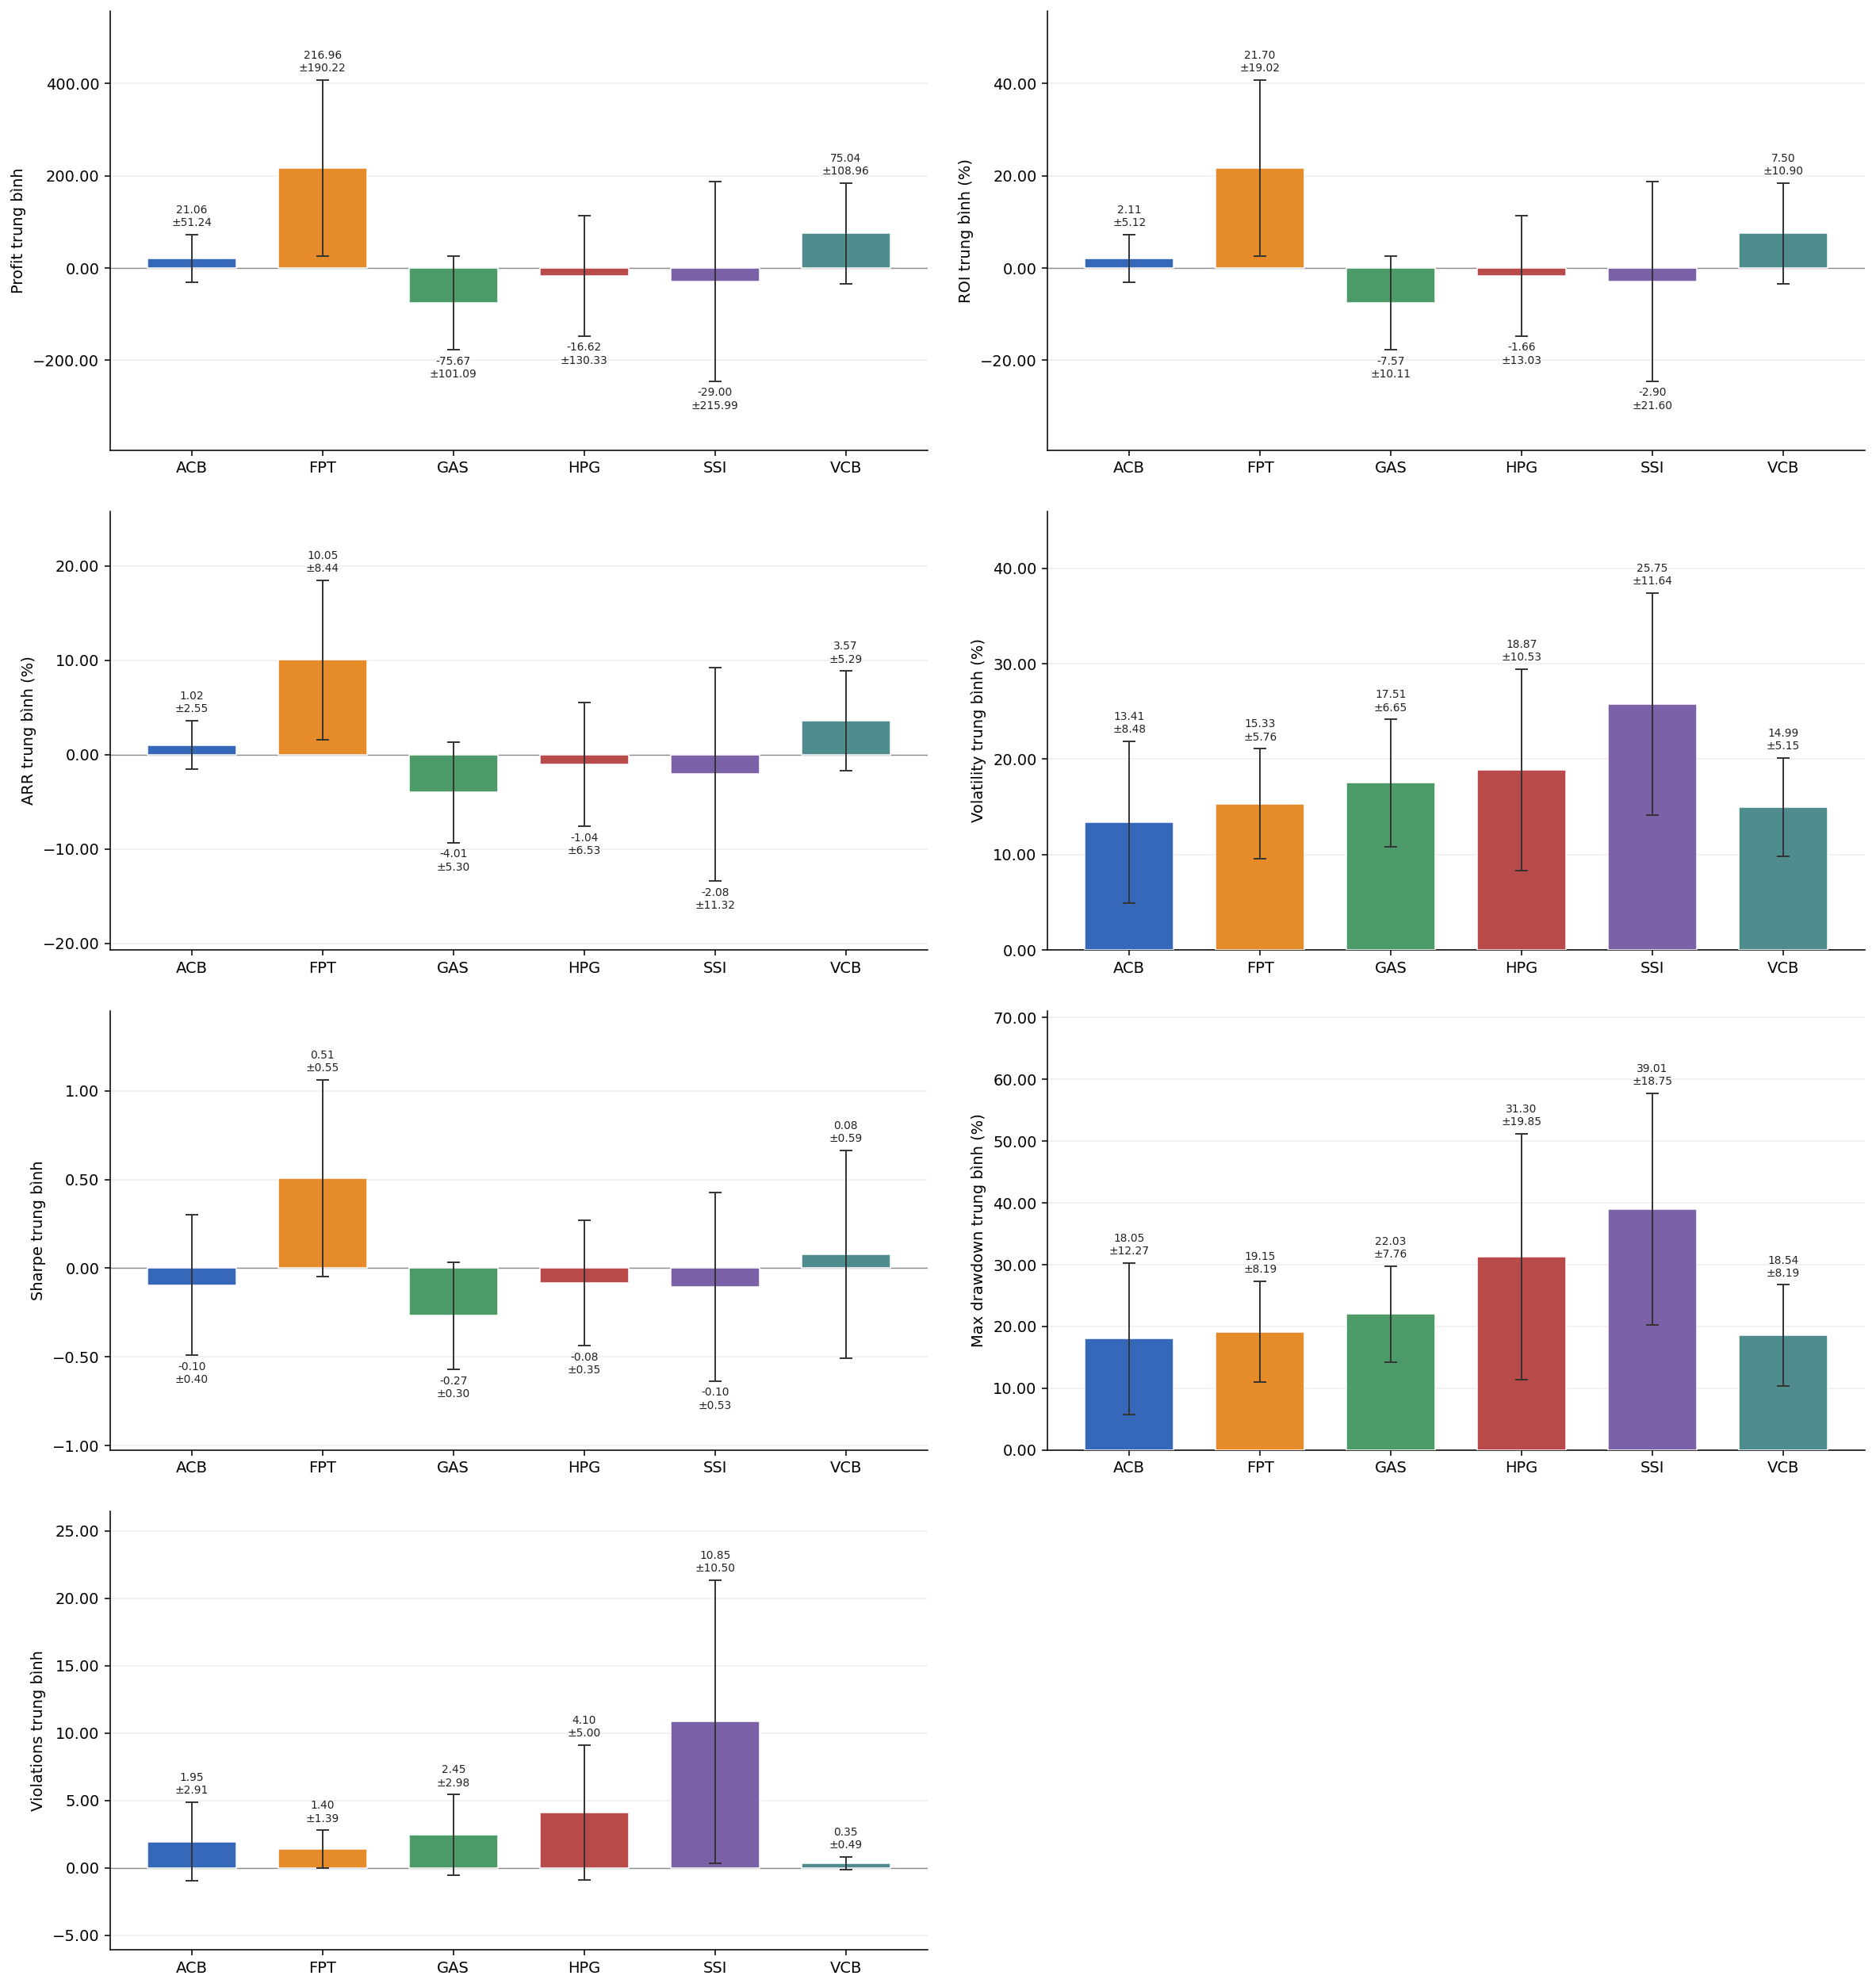

In [10]:
plot_case_across_tickers('without_vae')

### Case 2 — Without Cost Network (`without_cost_network`)
Hình dưới đây trình bày case loại bỏ Cost Network trên toàn bộ 6 cổ phiếu.

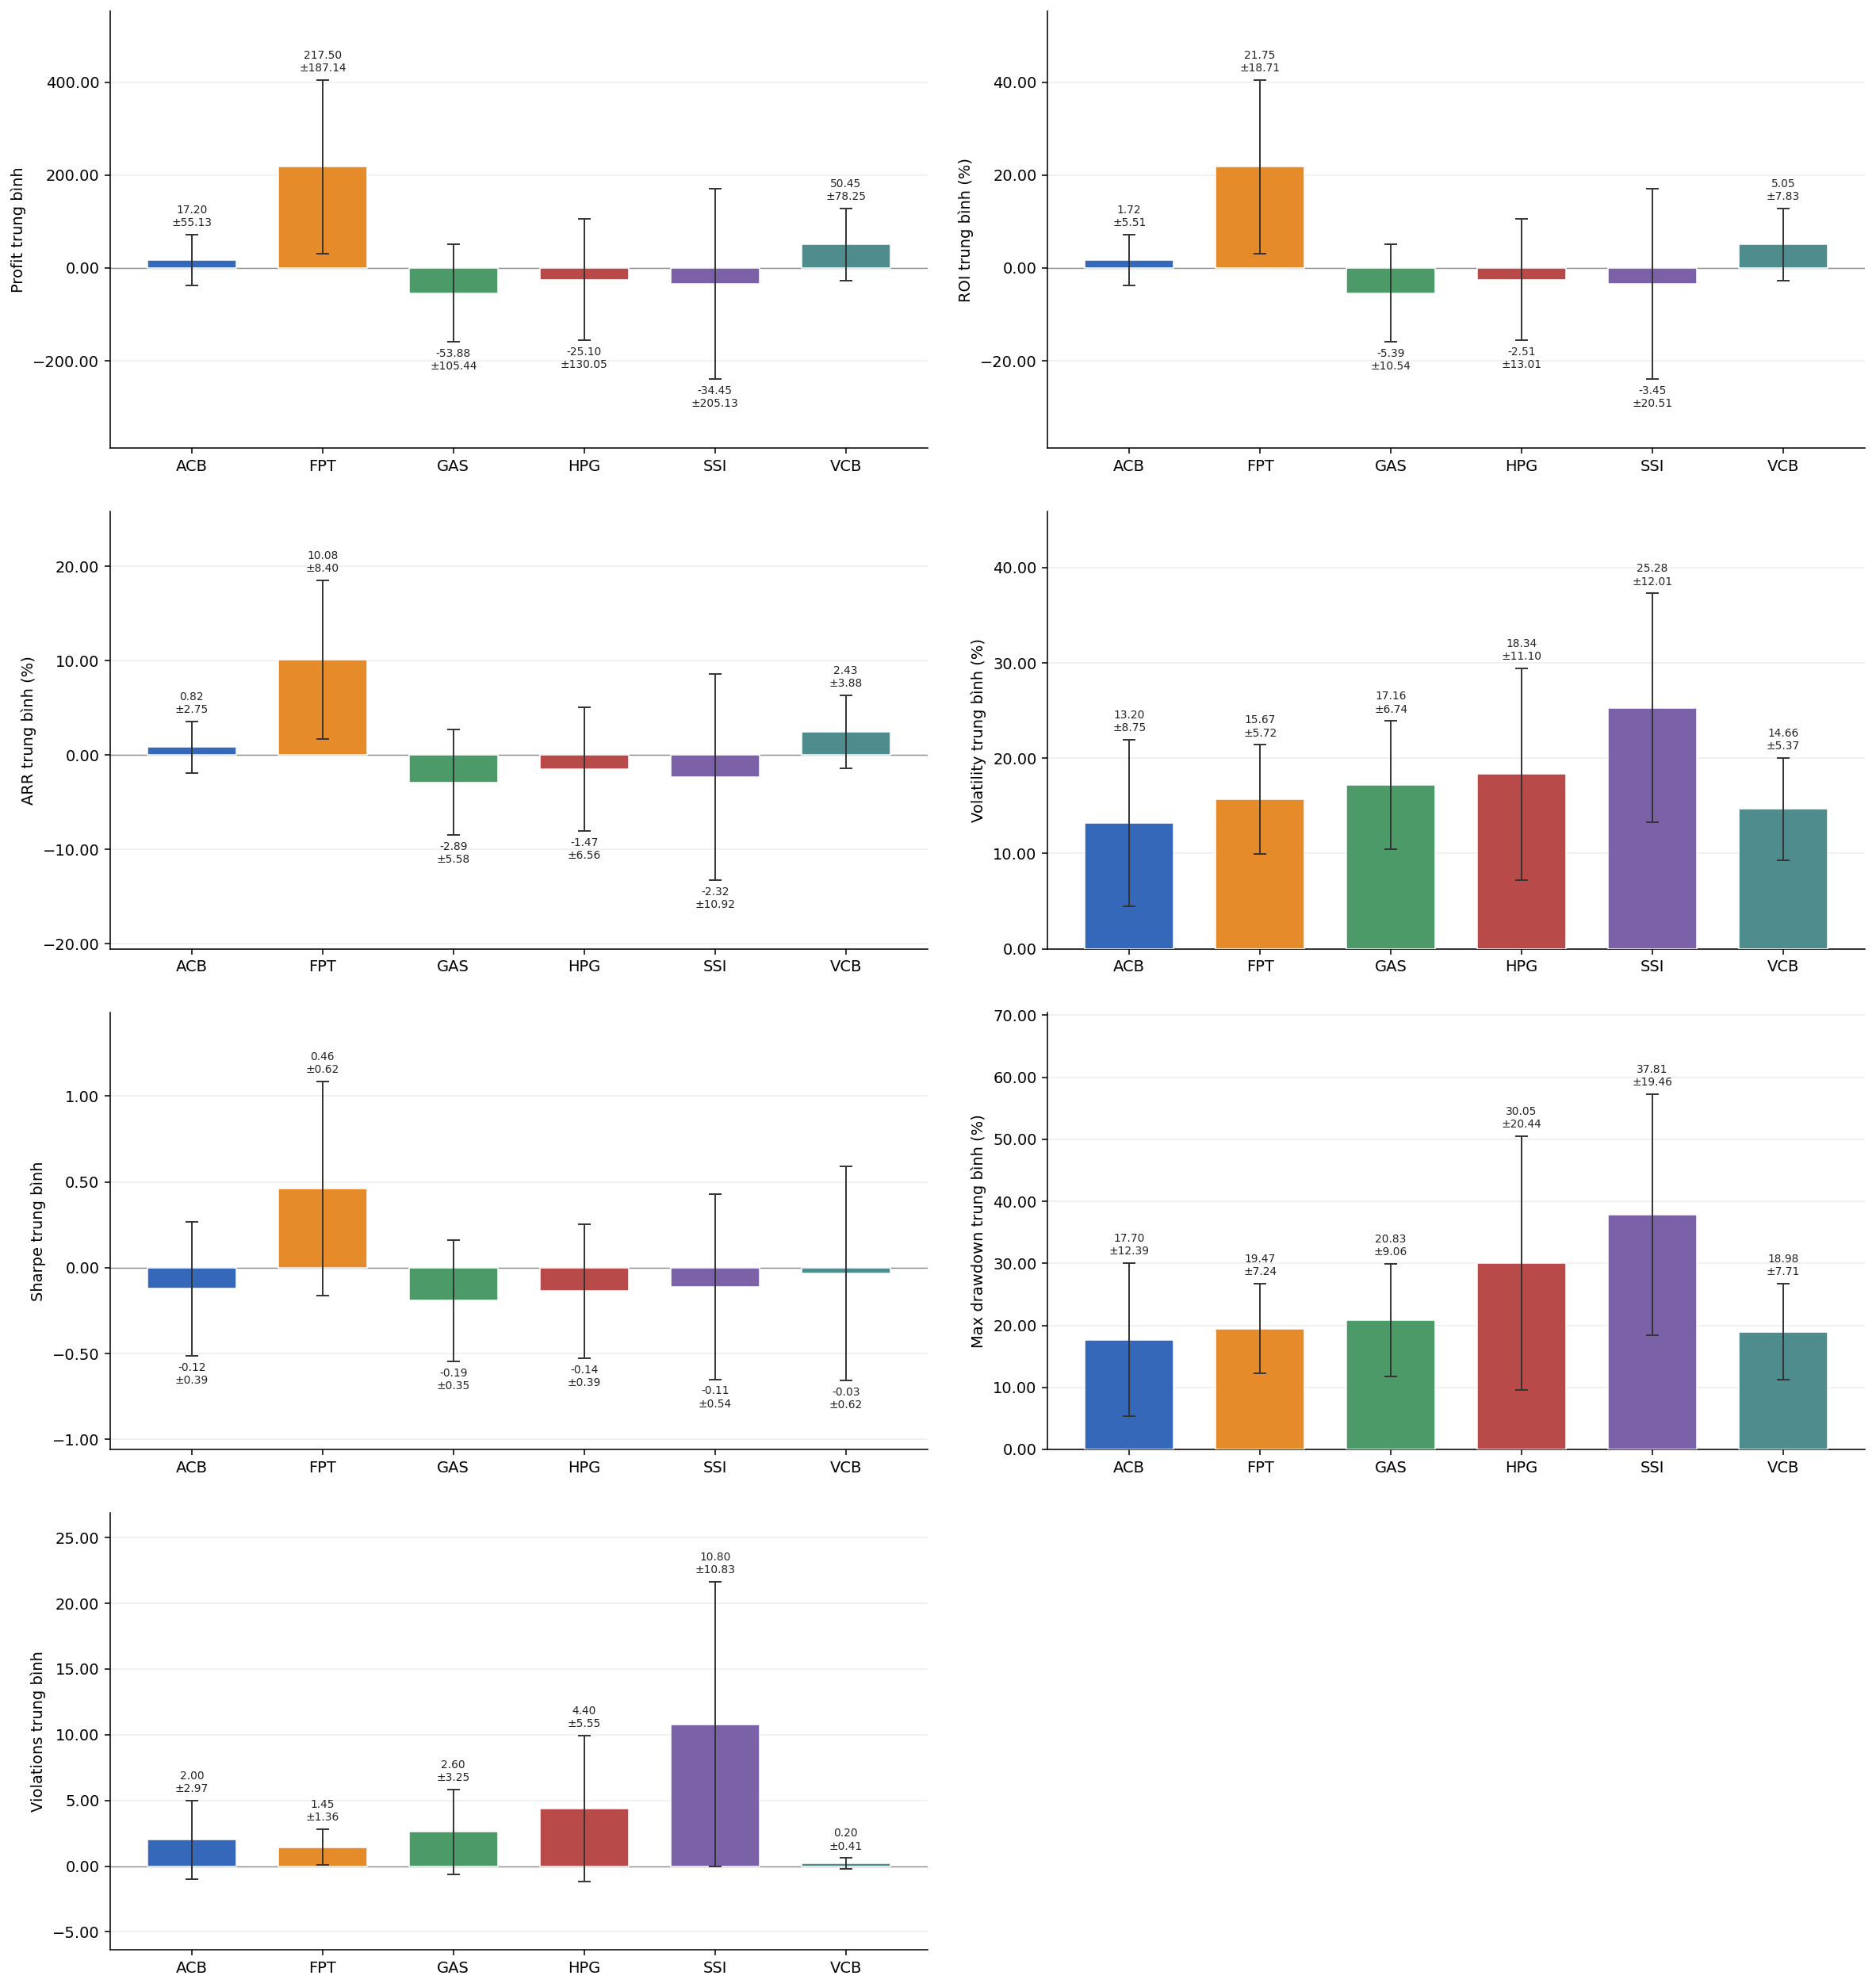

In [11]:
plot_case_across_tickers('without_cost_network')

### Case 3 — Without Confidence Weighting (`without_confident_weighting`)
Hình dưới đây trình bày case loại bỏ Confidence Weighting trên toàn bộ 6 cổ phiếu.

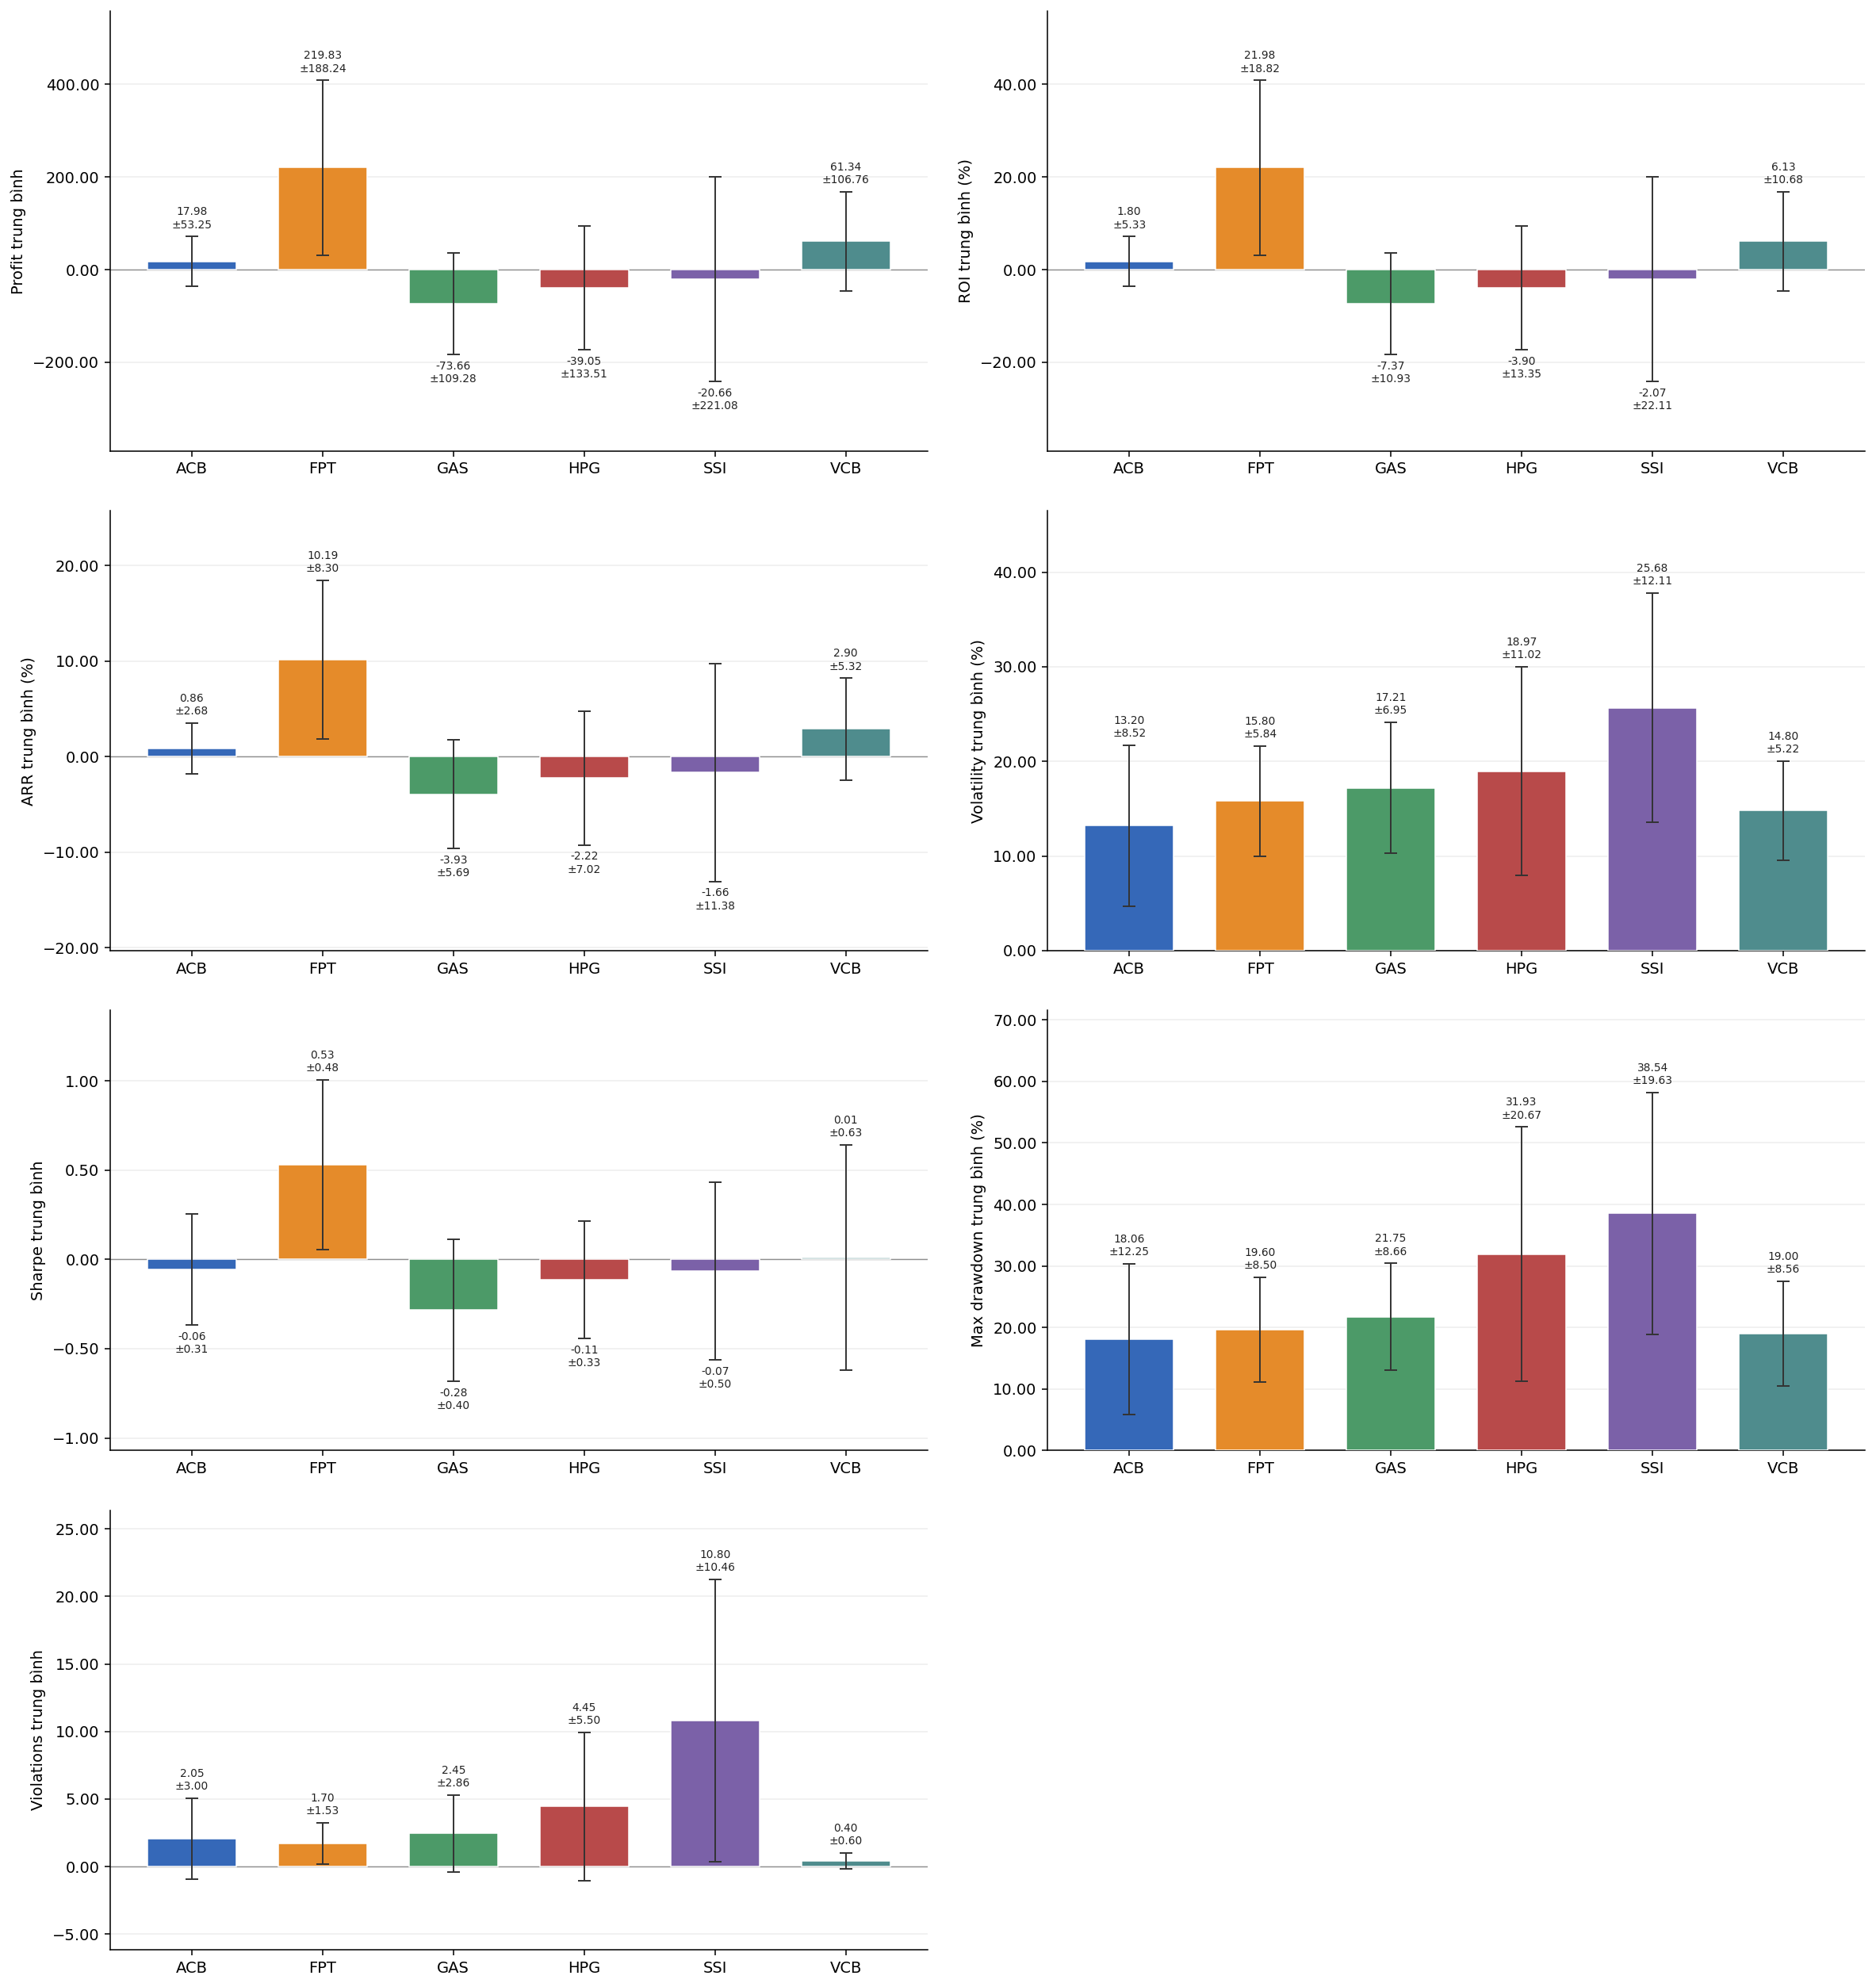

In [12]:
plot_case_across_tickers('without_confident_weighting')

---
Kết thúc phần trực quan hóa. Notebook không tạo hoặc lưu bất kỳ tệp hình ảnh nào.